---
# <div align="center"> COSC 2779 |  Deep Learning | Assignment 1 </div>
### <div align="center"> Xiaona Ma (s3825356)</div>
---

# Introduction

> This project tackles a practical, one-shot workflow for reading white-blood-cell smear images. From a single photo, our model predicts **four things at once**: the **cell type** (5 classes), **cell shape** (round/irregular), **nucleus shape** (6 fine-grained classes), and whether **cytoplasmic vacuoles** are present (yes/no). The data aren’t perfectly balanced—e.g., **Neutrophil is the largest group (~32%)** while **Lymphocyte is much smaller (~12%)**, **round cell shapes dominate (~78%)**, and **vacuole “yes” is rare (~7%)**—so our pipeline is designed with imbalance in mind.

> Our approach is simple and pragmatic: quick EDA, careful **combo-aware splitting** to keep rare label combinations in train, light but effective **data augmentation**, and a compact **multi-task MobileNetV2** backbone with four heads. I use **class/sample weighting** to protect minority classes and train in **two stages**: first the heads (frozen backbone), then a **small-LR fine-tune** of the last **~20 layers**.

> In short, this setup delivers a strong, well-balanced model: on the test set I reach about **~0.97** accuracy for cell type, **~0.87** for cell shape, **~0.85** for vacuoles, and **~0.67** for the harder nucleus shapes. It’s lightweight, reproducible, and ready to run on future images.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # 0=all, 1=INFO off, 2=INFO+WARNING off, 3=ERROR only
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"  # Disable XLA to prevent triggering registration

In [2]:
import tensorflow as tf
tf.config.optimizer.set_jit(False)
print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

2025-09-07 00:15:02.140021: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-07 00:15:02.164058: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-07 00:15:02.164083: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TF: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!pip install pydot
!pip install graphviz

In [4]:
import joblib
import pathlib
import tempfile
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers
from tensorflow import keras
from scipy.stats import chi2_contingency
from matplotlib.gridspec import GridSpec

In [5]:
# ---------------------- Global Parameter Setting ----------------------
SEED = 42
BATCH = 32
TARGET_SIZE = (224, 224)
IMG_DIR = './Hematoxylin'

np.random.seed(SEED)
tf.random.set_seed(SEED)

# Set the TensorBoard log directory
logdir = pathlib.Path(tempfile.mkdtemp()) / "tensorboard_logs"
shutil.rmtree(logdir, ignore_errors=True)
%load_ext tensorboard

In [6]:
# Create Folders
os.makedirs('images', exist_ok=True)
os.makedirs('joblibs', exist_ok=True)
os.makedirs('logs', exist_ok=True)
os.makedirs('saved_models', exist_ok=True)

# Part 1. Data Exploration

## 1.1 Loading CSV Data

In [7]:
# ---------------------- Load Files ----------------------
data_df = pd.read_csv('dev_data_2025.csv')
print("Dev Data Shape:", data_df.shape)
print('Dev Data Info:')
display(data_df.head())

Dev Data Shape: (5000, 5)
Dev Data Info:


,imageID,label,cell_shape,nucleus_shape,cytoplasm_vacuole
0,Img_00001,Lymphocyte,round,unsegmented-round,no
1,Img_00002,Monocyte,irregular,unsegmented-indented,no
2,Img_00003,Monocyte,irregular,irregular,yes
3,Img_00004,Basophil,round,segmented-multilobed,no
4,Img_00005,Neutrophil,round,unsegmented-band,no


In [8]:
# ---------------------- Checking Value Info ----------------------
print(f"Number of Dataset: {len(data_df)}")
print(f"Number of Class Label: {data_df['label'].nunique()}")
print(f"Number of Cell Shape: {data_df['cell_shape'].nunique()}")
print(f"Number of Nucleus Shape: {data_df['nucleus_shape'].nunique()}")
print(f"Number of Cytoplasm Vacuole: {data_df['cytoplasm_vacuole'].nunique()}")

Number of Dataset: 5000
Number of Class Label: 5
Number of Cell Shape: 2
Number of Nucleus Shape: 6
Number of Cytoplasm Vacuole: 2


In [9]:
##### ---------------------- View Unique Values For Each Attribute ----------------------
for col in ["label", "cell_shape", "nucleus_shape", "cytoplasm_vacuole"]:
    print(f"Attribute: {col} \n", data_df[col].unique())
    print('='*50+"\n")

Attribute: label 
 ['Lymphocyte' 'Monocyte' 'Basophil' 'Neutrophil' 'Eosinophil']

Attribute: cell_shape 
 ['round' 'irregular']

Attribute: nucleus_shape 
 ['unsegmented-round' 'unsegmented-indented' 'irregular'
 'segmented-multilobed' 'unsegmented-band' 'segmented-bilobed']

Attribute: cytoplasm_vacuole 
 ['no' 'yes']



## 1.2 Cleaning Data

In [10]:
# ---------------------- Checking Missing Value ----------------------
print("Missing value checking for data: ")
print(data_df.isnull().sum())

Missing value checking for data: 
imageID              0
label                0
cell_shape           0
nucleus_shape        0
cytoplasm_vacuole    0
dtype: int64


In [11]:
# ---------------------- Checking Duplicated Value ----------------------
print(f"Number of duplicate rows: {data_df.duplicated().sum()}")

Number of duplicate rows: 0


In [12]:
# ---------------------- Verify the Image Paths Exist ----------------------
image_paths = [os.path.join(IMG_DIR, f"{img_id}.jpg") for img_id in data_df['imageID']]
valid_paths = []

for path in image_paths:
    if os.path.exists(path):
        valid_paths.append(path)
    else:
        print(f"Warning: The image file does not exist: {path}")

print(f"Number of valid images: {len(valid_paths)}/{len(image_paths)}")

Number of valid images: 5000/5000


#### 💬 Oberservation

> I can see the development dataset contains 5,000 white blood cell images with multi-label annotations. Each sample includes:
> 
> **imageID**: Image identifier
> 
> **label**: Cell type (5 classes: Lymphocyte, Monocyte, Basophil, Neutrophil, Eosinophil)
> 
> **cell_shape**: Morphology (2 classes: round, irregular)
> 
> **nucleus_shape**: Nuclear structure (6 classes)
> 
> **cytoplasm_vacuole**: Vacuole presence (2 classes: no, yes)
> 
> The dataset is clean with no missing values, supporting multi-task CNN development for simultaneous cell classification and morphological feature extraction.

## 1.3 EDA

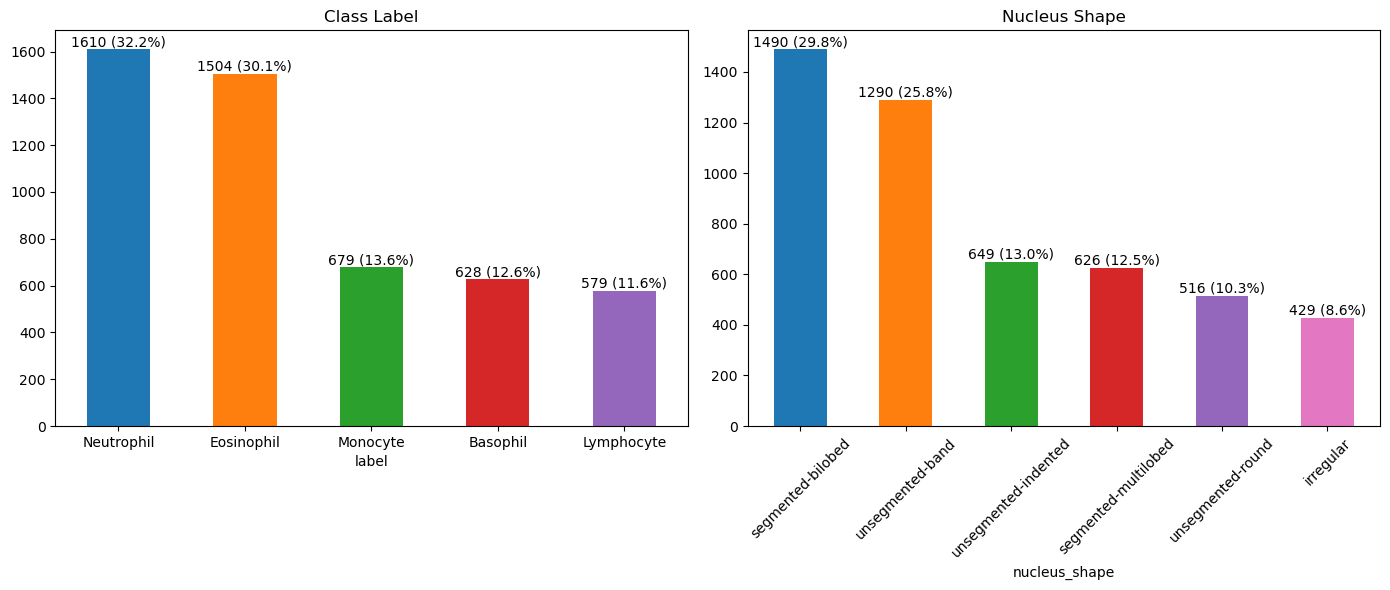

In [13]:
# ---------------------- Category Distribution Display ----------------------

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink']
plt.figure(figsize=(14, 6))

# Class Lable Plog
plt.subplot(1, 2, 1)
ax1 = data_df['label'].value_counts().plot(kind='bar', color=colors[:len(data_df['label'].value_counts())])
plt.title('Class Label')
plt.xticks(rotation=0)

total1 = data_df['label'].value_counts().sum()
ax1.bar_label(
    ax1.containers[0],
    labels=[f'{v.get_height()} ({v.get_height()/total1:.1%})' for v in ax1.containers[0]]
)

# Cell Shape Plog
plt.subplot(1, 2, 2)
ax2 = data_df['nucleus_shape'].value_counts().plot(kind='bar', color=colors[:len(data_df['nucleus_shape'].value_counts())])
plt.title('Nucleus Shape')
plt.xticks(rotation=45)

total2 = data_df['nucleus_shape'].value_counts().sum()
ax2.bar_label(
    ax2.containers[0],
    labels=[f'{v.get_height()} ({v.get_height()/total2:.1%})' for v in ax2.containers[0]]
)

plt.tight_layout()
plt.savefig('./images/class_distribution-1.png')
plt.show()

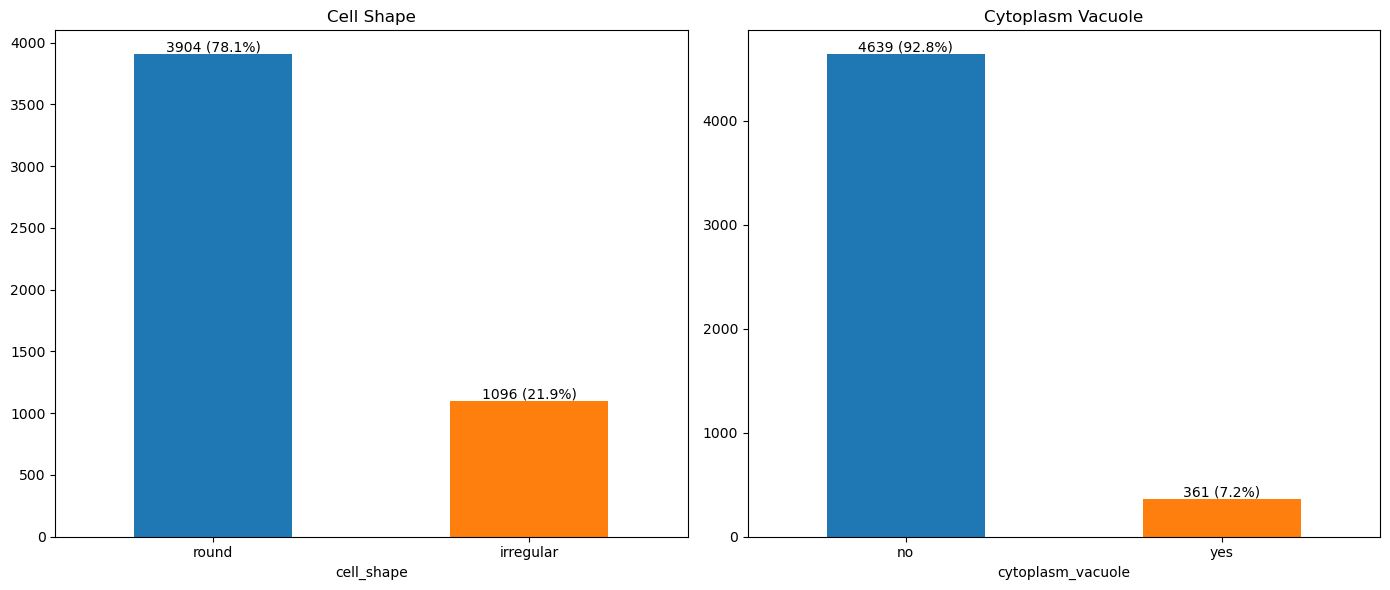

In [14]:
plt.figure(figsize=(14, 6))

# Nucleus Shape Plog
plt.subplot(1, 2, 1)
ax3 = data_df['cell_shape'].value_counts().plot(kind='bar', color=colors[:len(data_df['cell_shape'].value_counts())])
plt.title('Cell Shape')
plt.xticks(rotation=0)

total3 = data_df['cell_shape'].value_counts().sum()
ax3.bar_label(
    ax3.containers[0],
    labels=[f'{v.get_height()} ({v.get_height()/total3:.1%})' for v in ax3.containers[0]]
)

# Cytoplasm Vacuole Plog
plt.subplot(1, 2, 2)
ax4 = data_df['cytoplasm_vacuole'].value_counts().plot(kind='bar', color=colors[:len(data_df['cytoplasm_vacuole'].value_counts())])
plt.title('Cytoplasm Vacuole')
plt.xticks(rotation=0)

total4 = data_df['cytoplasm_vacuole'].value_counts().sum()
ax4.bar_label(
    ax4.containers[0],
    labels=[f'{v.get_height()} ({v.get_height()/total4:.1%})' for v in ax4.containers[0]]
)

plt.tight_layout()
plt.savefig('./images/class_distribution-2.png')
plt.show()

#### 💬 Oberservation
> From the charts I can see that neutrophils are the largest group with about 32% of the samples, while lymphocytes are the smallest with just around 12%. For cell shape, the majority are round (78%), and nucleus types like segmented or band forms together make up more than half of the data. Cytoplasm vacuoles are very rare, only about 7%.
>
> This imbalance means the model could get biased toward the bigger groups, like neutrophils or round cells, and miss the smaller ones. To handle this, later in training I applied **data augmentation** and **class weighting** so that the under-represented groups get more attention.

## 1.4 Display Sample Images

In [15]:
# ---------------------- Random Images Display ----------------------

def show_random_examples(field):
    classes = data_df[field].unique()
    num_classes = len(classes)

    fig, axes = plt.subplots(num_classes, 5, figsize=(5, num_classes + 1))

    for r, cls in enumerate(classes):
        subset = data_df[data_df[field] == cls].sample(5)
        
        for c, (_, row) in enumerate(subset.iterrows()):
            img_name = str(row['imageID'])
            if not img_name.lower().endswith('.jpg'):
                img_name = f"{img_name}.jpg"
            img_path = os.path.join(IMG_DIR, img_name)
            
            if c == 0: axes[r, c].set_title(cls)
            ax = axes[r][c]
            ax.imshow(Image.open(img_path))
            ax.axis("off")

    plt.suptitle(f"Representative Images by {field}")
    plt.tight_layout()
    plt.show()

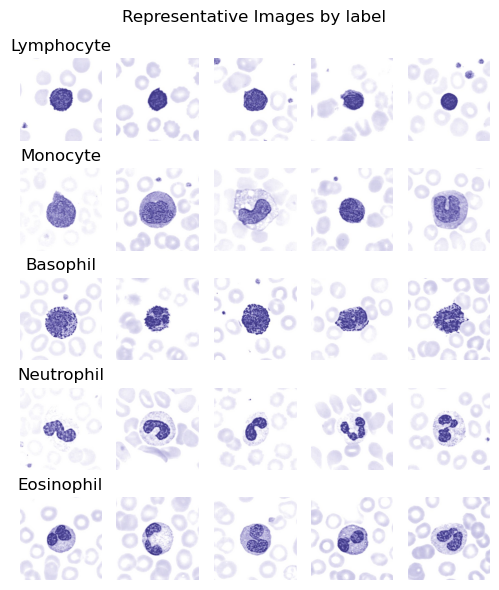

In [16]:
show_random_examples('label')

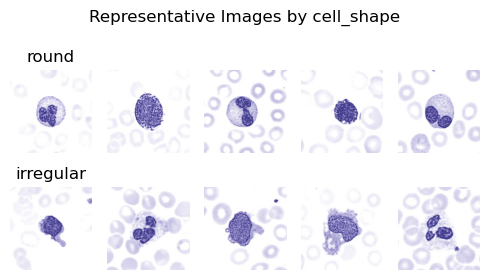

In [17]:
show_random_examples('cell_shape')

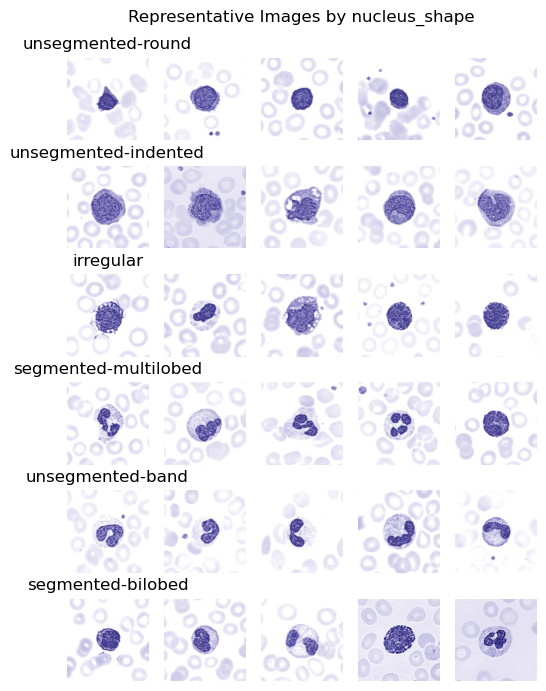

In [18]:
show_random_examples('nucleus_shape')

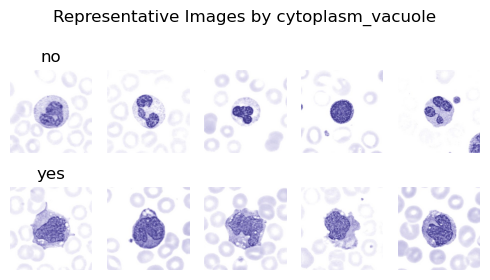

In [19]:
show_random_examples('cytoplasm_vacuole')

#### 💬 Oberservation
> Along with the bar charts, I also looked at some random sample images for each class. This helps us visually check that the dataset matches our expectations — for example, neutrophils really are the most common, and I can clearly see the difference between round and irregular cell shapes. It also highlights that vacuoles are quite rare, since there are only a few examples across all the samples.

## 1.5 Image Size Check

In [20]:
# ---------------------- Check Image Dataset ----------------------
def check_image() :
    image_files = [
        fname for fname in os.listdir(IMG_DIR)
        if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    
    # Read the dimensions of each image and calculate the area
    areas = []
    for fname in image_files:
        path = os.path.join(IMG_DIR, fname)
        with Image.open(path) as img:
            areas.append(img.size)
    
    areas = np.array(areas)
    
    # Calculate mean and standard deviation
    mean_image_size = np.mean(areas, axis=0)
    std_image_size  = areas.std()
    
    print(f"Image Size Mean: {mean_image_size}")
    print(f"Image Size Standard Deviation: {std_image_size:.2f}")

check_image()

Image Size Mean: [360.14565935 363.14565935]
Image Size Standard Deviation: 1.76


#### 💬 Oberservation
> I also checked the raw image sizes. On average, the images are about **360 × 363** pixels, and the standard deviation is very small (≈1.8). This tells us that the dataset is very consistent in image dimensions, which makes preprocessing easier. Later I will still resize all images to **224 × 224** so that they match the input requirement of the CNN model.

# Part 2. Data Preprocessing & Spliting

## 2.1 Data Preprocessing

In [21]:
# ---------------------- Label Encoding ----------------------
# Initializing encoder
label_encoder = LabelEncoder()
cell_shape_encoder = LabelEncoder()
nucleus_shape_encoder = LabelEncoder()
vacuole_encoder = LabelEncoder()

# Quasi-merged conversion label
data_df['label_encoded'] = label_encoder.fit_transform(data_df['label'])
data_df['cell_shape_encoded'] = cell_shape_encoder.fit_transform(data_df['cell_shape'])
data_df['nucleus_shape_encoded'] = nucleus_shape_encoder.fit_transform(data_df['nucleus_shape'])
data_df['vacuole_encoded'] = vacuole_encoder.fit_transform(data_df['cytoplasm_vacuole'])

# View encoding mapping
print("Label Mapping:\t\t", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))
print("Cell Shape Mapping:\t", dict(zip(cell_shape_encoder.classes_, range(len(cell_shape_encoder.classes_)))))
print("Nucleus Shape Mapping:\t", dict(zip(nucleus_shape_encoder.classes_, range(len(nucleus_shape_encoder.classes_)))))
print("Vacuole Mapping:\t", dict(zip(vacuole_encoder.classes_, range(len(vacuole_encoder.classes_)))))

Label Mapping:		 {'Basophil': 0, 'Eosinophil': 1, 'Lymphocyte': 2, 'Monocyte': 3, 'Neutrophil': 4}
Cell Shape Mapping:	 {'irregular': 0, 'round': 1}
Nucleus Shape Mapping:	 {'irregular': 0, 'segmented-bilobed': 1, 'segmented-multilobed': 2, 'unsegmented-band': 3, 'unsegmented-indented': 4, 'unsegmented-round': 5}
Vacuole Mapping:	 {'no': 0, 'yes': 1}


#### 💬 Oberservation

> To prepare the data for training, I converted all categorical labels into numbers using LabelEncoder. For example, the five white blood cell types are mapped as: **Basophil → 0, Eosinophil → 1, Lymphocyte → 2, Monocyte → 3, Neutrophil → 4**. Similarly, cell shape is encoded as irregular (0) and round (1). Nucleus shape has six categories, and vacuole presence is simply no (0) and yes (1). This way, the model can work with numerical targets while still keeping the biological meaning behind each class.

In [22]:
# ---------------------- Load and Preprocess Image ----------------------
def load_and_preprocess(path):
    img = tf.io.read_file(path)                         # Read file
    img = tf.image.decode_jpeg(img, channels=3)         # Guaranteed 3-channel
    img = tf.image.resize(img, TARGET_SIZE)             # Uniformly resize to 224×224
    img = tf.cast(img, tf.float32)
    return img

In [23]:
# ---------------------- Define Data Augmentation Function ----------------------
def augment(image, label):
    H = tf.cast(TARGET_SIZE[0], tf.int32)
    W = tf.cast(TARGET_SIZE[1], tf.int32)

    # Translation: realized by symmetrical filling and random cropping
    translate_frac = 0.03
    pad_h = tf.cast(tf.round(translate_frac * tf.cast(H, tf.float32)), tf.int32)
    pad_w = tf.cast(tf.round(translate_frac * tf.cast(W, tf.float32)), tf.int32)
    image = tf.pad(image, [[pad_h, pad_h], [pad_w, pad_w], [0, 0]], mode='REFLECT')
    image = tf.image.random_crop(image, size=[H, W, 3])

    # Lightweight zoom: only zoom-in(0.95~1.0) to avoid filling artifacts caused by zoom-out
    scale = tf.random.uniform([], 0.95, 1.0)
    new_h = tf.cast(tf.round(scale * tf.cast(H, tf.float32)), tf.int32)
    new_w = tf.cast(tf.round(scale * tf.cast(W, tf.float32)), tf.int32)
    image = tf.image.resize(image, (new_h, new_w), antialias=True)
    image = tf.image.resize_with_crop_or_pad(image, H, W)

    # Turn left and right
    image = tf.image.random_flip_left_right(image)
    image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))

    # Lightweight color disturbance
    image = tf.image.random_brightness(image, max_delta=0.03)
    image = tf.image.random_contrast(image, lower=0.98, upper=1.02)

    # Ensure that the pixel value is within the valid range.
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, label

#### 💬 Oberservation
> All images are first resized to **224×224** pixels so they match the CNN input size. During training, I also apply light data augmentation to improve generalization. This includes small translations (±3%), slight zoom-in, random flips, and rotations. I also add minor brightness and contrast changes. These operations simulate real-world variations without distorting the biological structure of the cells. Finally, I clip pixel values to keep them in the valid range.

In [24]:
# ---------------------- Create TensorFlow Dataset ----------------------

def create_dataset(image_paths, labels, training = True):
    # 1. Create a dataset from a tensor
    path_ds = tf.data.Dataset.from_tensor_slices(image_paths)
    
    # 2. Parallel loading and preprocessing
    image_ds = path_ds.map( load_and_preprocess, num_parallel_calls = tf.data.AUTOTUNE)
    
    # 3. Create a labeled dataset
    label_ds = tf.data.Dataset.from_tensor_slices(labels)
    
    # 4. Merge pictures and labels
    dataset = tf.data.Dataset.zip((image_ds, label_ds))
    
    # Data Augmentation (for training set only)
    if training:
        dataset = dataset.shuffle(buffer_size = 1000)
        dataset = dataset.map(augment, num_parallel_calls = tf.data.AUTOTUNE)
    
    # batch processing
    dataset = dataset.batch(BATCH)
    
    # Prefetching data to improve performance
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

#### 💬 Consistency in Preprocessing

> I built a TensorFlow dataset pipeline to handle image loading and preprocessing. First, the image paths and labels are matched together. Then:
> 
> - For the **training set**, I shuffle the data, apply augmentation, and batch it into groups.
> - For the **validation/test sets**, I skip augmentation so they reflect the true data distribution.
> - Finally, I use **prefetching** so the GPU can keep training without waiting for the data.
>
> This setup makes the whole training process more efficient and ensures consistency across all splits.

## 2.2 Split the Dataset

In [25]:
# Combined layered key
combo = data_df[['label','cell_shape','nucleus_shape','cytoplasm_vacuole']].astype(str).agg('|'.join, axis=1)
combo_df = data_df.assign(_combo = combo)

# Found a combo that only occurs once.
vc = combo_df['_combo'].value_counts()

# The safety net for extremely low-frequency combinations
rare_threshold = 3
rare_keys = vc[vc < rare_threshold].index

df_rare = combo_df[combo_df['_combo'].isin(rare_keys)]
df_rest = combo_df[~combo_df['_combo'].isin(rare_keys)]

# 1. combine and stratify the hierarchical data.
train_rest, temp_df = train_test_split(
    df_rest,
    test_size=0.3,
    random_state=SEED,
    stratify=df_rest['_combo']
)

# Training set = layered training + rare
train_df = pd.concat([train_rest, df_rare], ignore_index=True)

# 2. Divide temp into val/test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df['label']
)

# Clean up _combo columns
for df in (train_df, val_df, test_df):
    df.drop(columns=['_combo'], inplace=True)
    df.sort_index(inplace=True)

# Double insurance: shuffle
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = val_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# The combined entity equals the original scale.
# all_idx = set(train_df.index) | set(val_df.index) | set(test_df.index)
print(f'Data Set without overlap: {len(train_df) + len(val_df) + len(test_df) == len(combo_df)}')

Data Set without overlap: True


In [26]:
print(f"Dataset split:")
print(f"Training set:\t {len(train_df)} samples")
print(f"Validation set:\t {len(val_df)} samples")
print(f"Test set:\t {len(test_df)} samples")

Dataset split:
Training set:	 3507 samples
Validation set:	 746 samples
Test set:	 747 samples


#### 💬 Data Splitting Strategy

>I used a **combinational stratified splitting strategy** for the following reasons:

> 1. Make sure the training set includes all possible feature combinations, so validation/test sets don’t contain unseen patterns.
> 2. Handle rare combinations (those that appear only once) by placing them all in the training set.
> 3. Use stratified sampling to keep the main class distribution balanced.

In [27]:
# Create corrected sample weights
def create_sample_weights(train_df):
    # Calculate category weights
    label_weights = compute_class_weight(
        'balanced', classes=np.unique(train_df['label_encoded']), 
        y=train_df['label_encoded']
    )
    
    cell_shape_weights = compute_class_weight(
        'balanced', classes=np.unique(train_df['cell_shape_encoded']), 
        y=train_df['cell_shape_encoded']
    )
    
    nucleus_shape_weights = compute_class_weight(
        'balanced', classes=np.unique(train_df['nucleus_shape_encoded']), 
        y=train_df['nucleus_shape_encoded']
    )
    
    vacuole_weights = compute_class_weight(
        'balanced', classes=np.unique(train_df['vacuole_encoded']), 
        y=train_df['vacuole_encoded']
    )
    
    return {
        'label': dict(enumerate(label_weights)),
        'cell_shape': dict(enumerate(cell_shape_weights)),
        'nucleus_shape': dict(enumerate(nucleus_shape_weights)),
        'vacuole': dict(enumerate(vacuole_weights))
    }

class_weights = create_sample_weights(train_df)

print("Category weight:", class_weights)

Category weight: {'label': {0: 1.5904761904761904, 1: 0.6642045454545454, 2: 1.7275862068965517, 3: 1.473529411764706, 4: 0.6218085106382979}, 'cell_shape': {0: 2.2772727272727273, 1: 0.6406649616368286}, 'nucleus_shape': {0: 1.941860465116279, 1: 0.5593301435406699, 2: 1.3314350797266514, 3: 0.6480044345898004, 4: 1.2789934354485777, 5: 1.6101928374655647}, 'vacuole': {0: 0.5393725007689941, 1: 6.849609375}}


In [28]:
# Save the encoder for later use.
joblib.dump(label_encoder, './joblibs/label_encoder.pkl')
joblib.dump(cell_shape_encoder, './joblibs/cell_shape_encoder.pkl')
joblib.dump(nucleus_shape_encoder, './joblibs/nucleus_shape_encoder.pkl')
joblib.dump(vacuole_encoder, './joblibs/vacuole_encoder.pkl')

['./joblibs/vacuole_encoder.pkl']

#### 💬 Sample Weights

> To deal with the strong class imbalance, I calculated **sample weights** for each prediction task (label, cell shape, nucleus shape, vacuole). For example, rare classes like Lymphocyte or vacuole “yes” get a higher weight, while common classes like Neutrophil or “no vacuole” get a lower weight.
>
> These weights are later passed to the loss function so that the model does not get biased toward the big classes. This way, even the smaller groups have a fair chance of being learned by the network.

In [29]:
# ---------------------- Create Training, Validation, and Test Datasets ----------------------
train_dataset = create_dataset(
    [os.path.join(IMG_DIR, f"{img_id}.jpg") for img_id in train_df['imageID']],
    {
        'label': train_df['label_encoded'].values,
        'cell_shape': train_df['cell_shape_encoded'].values,
        'nucleus_shape': train_df['nucleus_shape_encoded'].values,
        'vacuole': train_df['vacuole_encoded'].values
    },
    training=True
)

val_dataset = create_dataset(
    [os.path.join(IMG_DIR, f"{img_id}.jpg") for img_id in val_df['imageID']],
    {
        'label': val_df['label_encoded'].values,
        'cell_shape': val_df['cell_shape_encoded'].values,
        'nucleus_shape': val_df['nucleus_shape_encoded'].values,
        'vacuole': val_df['vacuole_encoded'].values
    },
    training=False
)

test_dataset = create_dataset(
    [os.path.join(IMG_DIR, f"{img_id}.jpg") for img_id in test_df['imageID']],
    {
        'label': test_df['label_encoded'].values,
        'cell_shape': test_df['cell_shape_encoded'].values,
        'nucleus_shape': test_df['nucleus_shape_encoded'].values,
        'vacuole': test_df['vacuole_encoded'].values
    },
    training=False
)

In [30]:
print("The dataset has been created!")
print(f"Training Set Batch: {len(train_dataset)}")
print(f"Validation Set Batch: {len(val_dataset)}")
print(f"Test Set Batch: {len(test_dataset)}")

The dataset has been created!
Training Set Batch: 110
Validation Set Batch: 24
Test Set Batch: 24


#### 💬 Create Datasets

> I finally created three TensorFlow datasets for training, validation, and testing. Each dataset pairs the image with a dictionary of labels:
>
> - **label** → WBC type (Basophil, Eosinophil, etc.)
> - **cell_shape** → round or irregular
> - **nucleus_shape** → six possible categories
> - **vacuole** → yes or no
> 
> For the training dataset, I applied augmentation and shuffling to improve generalization. Validation and test datasets are kept clean without augmentation, so they reflect the real-world distribution. This setup ensures that all four prediction tasks are aligned in one pipeline, ready for a single multi-output CNN model.

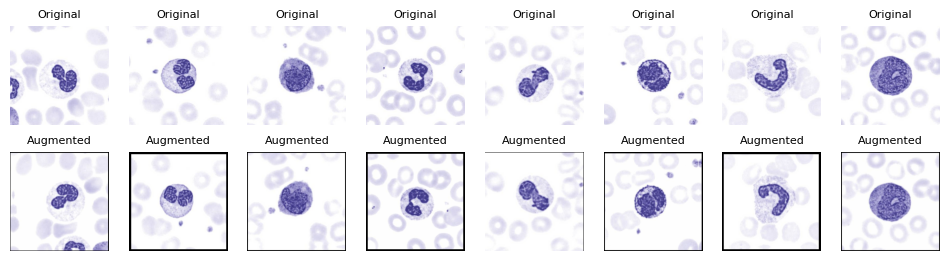

In [31]:
# ---------------------- Show the Data Augmentation Effect ----------------------
def show_augmentation_effect(dataset, num_examples=8):
    for images, labels in dataset.take(1):
        plt.figure(figsize = (12, 3))
        for i in range(num_examples):
            # Original Images
            plt.subplot(2, num_examples, i + 1)
            plt.imshow(tf.clip_by_value(images[i] / 255.0, 0.0, 1.0))
            plt.title("Original", fontsize=8)
            plt.axis('off')

            # Augmentated Images
            augmented_img = augment(images[i], labels)[0]
            plt.subplot(2, num_examples, num_examples + i + 1)
            plt.imshow(tf.clip_by_value(augmented_img / 255.0, 0.0, 1.0))
            plt.title("Augmented", fontsize = 8)
            plt.axis('off')
        plt.show()


train_dataset_raw = create_dataset(
    [os.path.join(IMG_DIR, f"{img_id}.jpg") for img_id in train_df['imageID']],
    {
        'label': train_df['label_encoded'].values,
        'cell_shape': train_df['cell_shape_encoded'].values,
        'nucleus_shape': train_df['nucleus_shape_encoded'].values,
        'vacuole': train_df['vacuole_encoded'].values
    },
    training=False
)
show_augmentation_effect(train_dataset_raw)

#### 💬 Visualizing Data Augmentation

> To confirm that our augmentation is working as intended, I plotted a few examples. The **top row** shows the original images, and the **bottom row** shows the same images after random transformations (flip, rotation, small zoom, brightness/contrast changes, etc.).
>
> This check is important because:
> - It reassures us that the augmentations are realistic (cells still look like cells, not distorted blobs).
> - It demonstrates how the model will see slightly different variations of the same data during training, which improves generalization.
> - It helps balance out the dataset, especially for smaller classes, by effectively creating more diverse training samples.

# Part 3. CNN Model Design

## 3.1 Baseline Model

In [32]:
# ---------------------- Build Baseline Model ----------------------
IMG_SHAPE = TARGET_SIZE + (3,)

def create_baseline_model():
    # Create the base model
    base_model = tf.keras.applications.MobileNetV2(
            input_shape = IMG_SHAPE,
            include_top = False,
            weights = 'imagenet'
        )
    
    # Freeze the weights of the base model
    # Prevent its parameters from updating
    base_model.trainable = False
    # MobileNetV2 normalization of input images (scaling to the range [-1,1]).
    preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
    
    # Define the input layer of the model
    inputs = tf.keras.Input(shape=IMG_SHAPE)
    
    # Perform data preprocessing
    x = preprocess_input(inputs)
    
    # Feed the image into MobileNetV2 to extract features (convolutional feature maps).
    x = base_model(x, training=False)
    
    # Perform global average pooling on the convolutional feature map to transform it into a vector.
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    
    # Create four output branches
    label = tf.keras.layers.Dense(5, activation='softmax', name='label')(x)
    
    cell_shape = tf.keras.layers.Dense(1, activation='sigmoid', name='cell_shape')(x)
    
    nucleus_shape = tf.keras.layers.Dense(6, activation='softmax', name='nucleus_shape')(x)
    
    vacuole = tf.keras.layers.Dense(1, activation='sigmoid', name='vacuole')(x)
    
    # Connect the input layer and output layer to form a complete model.
    model = tf.keras.Model(
        inputs=inputs, 
        outputs={
            "label":label,
            "cell_shape": cell_shape,
            "nucleus_shape": nucleus_shape,
            "vacuole": vacuole,
        },
    )
    return model, base_model

model, base_model = create_baseline_model()

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 tf.math.truediv (TFOpLambd  (None, 224, 224, 3)          0         ['input_2[0][0]']             
 a)                                                                                               
                                                                                                  
 tf.math.subtract (TFOpLamb  (None, 224, 224, 3)          0         ['tf.math.truediv[0][0]']     
 da)                                                                                              
                                                                                              

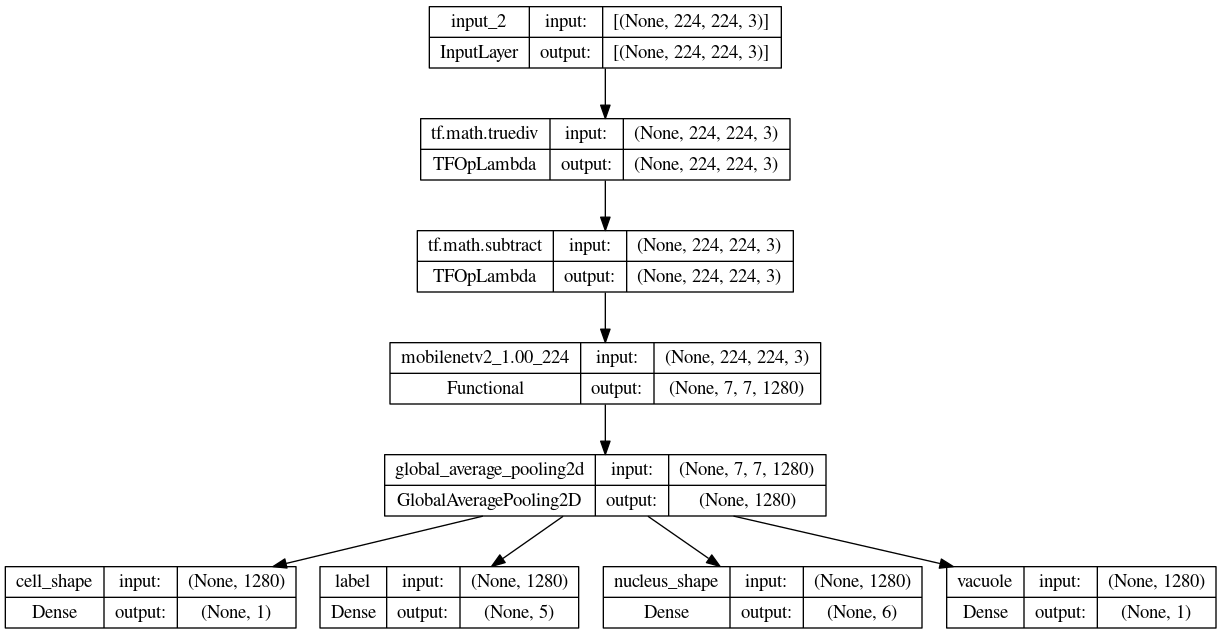

In [33]:
# Drawing the model architecture diagram
tf.keras.utils.plot_model(
    model,
    to_file = './images/base_model_architecture.png',
    show_shapes = True,
    show_layer_names = True,
    rankdir = 'TB',
    expand_nested = False,
    dpi = 96
)

#### 💬 Baseline Model Design

> I used **MobileNetV2 (pre-trained on ImageNet)** as the backbone for feature extraction. Its convolutional layers are frozen at first, so I can reuse its rich feature maps without overfitting.
>
> After extracting features, I applied **global average pooling** to flatten them into a vector. Then, I branched out into **four prediction heads**:
> - **label** → 5-way softmax (Basophil, Eosinophil, Lymphocyte, Monocyte, Neutrophil)
> - **cell_shape** → binary sigmoid (round / irregular)
> - **nucleus_shape** → 6-way softmax (various nucleus types)
> - **vacuole** → binary sigmoid (yes / no)
>
> This design directly matches the assignment requirement of building **one CNN that predicts both the WBC type and the key morphological features**.

## 3.2 Optimized Model Compilation

In [34]:
def build_losses():
    return {
        'label': tf.keras.losses.SparseCategoricalCrossentropy(),
        'cell_shape': tf.keras.losses.BinaryCrossentropy(),
        'nucleus_shape': tf.keras.losses.SparseCategoricalCrossentropy(),
        'vacuole': tf.keras.losses.BinaryCrossentropy(),
    }
    
def build_metrics():
    return {
        'label': [tf.keras.metrics.SparseCategoricalAccuracy(name='acc')],
        'cell_shape': [tf.keras.metrics.BinaryAccuracy(name='acc')],
        'nucleus_shape': [tf.keras.metrics.SparseCategoricalAccuracy(name='acc')],
        'vacuole': [tf.keras.metrics.BinaryAccuracy(name='acc')],
    }
    
BASIC_WEIGHT = {
        'label': 1.0,
        'cell_shape': 1.0,
        'nucleus_shape': 1.0,
        'vacuole': 1.0
    }

In [35]:
# Compile Model
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = build_losses(),
    metrics = build_metrics(),
    loss_weights = BASIC_WEIGHT
)

#### 💬 Loss & Metrics Setup

> I compiled the model with task-specific loss functions:
> - Sparse categorical cross-entropy for **multi-class outputs** (label, nucleus shape).
> - Binary cross-entropy for **binary outputs** (cell shape, vacuole).
> - Each output is evaluated with the matching accuracy metric.
>
> At this stage, I use equal loss weights for all four outputs. Later I can adjust these weights if I want to prioritize the main task (WBC type) over the auxiliary tasks.

## 3.3 Training Model

In [36]:
# ---------------------- Plot Training Curves ----------------------

def plot_training_curves(history, name):
    # Get History
    hist = history.history
    
    # Setting Plot Theme
    plt.style.use('seaborn-v0_8')
    
    # Create Plot
    fig, axes = plt.subplots(5, 2, figsize=(18, 15))
    fig.suptitle('Training Curves', fontsize=16, fontweight='bold')
    
    # 1. Total Loss
    axes[0, 0].plot(hist['loss'], label='Training Loss', color='blue')
    axes[0, 0].plot(hist['val_loss'], label='Validation Loss', color='red')
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Label: Loss and Accuracy Rate
    axes[1, 0].plot(hist['label_loss'], label='Training Loss', color='blue')
    axes[1, 0].plot(hist['val_label_loss'], label='Validation Loss', color='red')
    axes[1, 0].set_title('Label Loss')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(hist['label_acc'], label='Training Accuracy', color='blue')
    axes[1, 1].plot(hist['val_label_acc'], label='Validation Accuracy', color='red')
    axes[1, 1].set_title('Label Accuracy')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # 3. Cell Shape: Loss and Accuracy Rate
    axes[2, 0].plot(hist['cell_shape_loss'], label='Training Loss', color='blue')
    axes[2, 0].plot(hist['val_cell_shape_loss'], label='Validation Loss', color='red')
    axes[2, 0].set_title('Cell Shape Loss')
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_ylabel('Loss')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)
    
    axes[2, 1].plot(hist['cell_shape_acc'], label='Training Accuracy', color='blue')
    axes[2, 1].plot(hist['val_cell_shape_acc'], label='Validation Accuracy', color='red')
    axes[2, 1].set_title('Cell Shape Accuracy')
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].set_ylabel('Accuracy')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)
    
    # 4. Nuclear Shape: Loss and Accuracy Rate
    axes[3, 0].plot(hist['nucleus_shape_loss'], label='Training Loss', color='blue')
    axes[3, 0].plot(hist['val_nucleus_shape_loss'], label='Validation Loss', color='red')
    axes[3, 0].set_title('Nucleus Shape Loss')
    axes[3, 0].set_xlabel('Epoch')
    axes[3, 0].set_ylabel('Loss')
    axes[3, 0].legend()
    axes[3, 0].grid(True, alpha=0.3)
    
    axes[3, 1].plot(hist['nucleus_shape_acc'], label='Training Accuracy', color='blue')
    axes[3, 1].plot(hist['val_nucleus_shape_acc'], label='Validation Accuracy', color='red')
    axes[3, 1].set_title('Nucleus Shape Accuracy')
    axes[3, 1].set_xlabel('Epoch')
    axes[3, 1].set_ylabel('Accuracy')
    axes[3, 1].legend()
    axes[3, 1].grid(True, alpha=0.3)
    
    # 5. Cytoplasmic Vacuoles: Loss and Accuracy Rate
    axes[4, 0].plot(hist['vacuole_loss'], label='Training Loss', color='blue')
    axes[4, 0].plot(hist['val_vacuole_loss'], label='Validation Loss', color='red')
    axes[4, 0].set_title('Vacuole Loss')
    axes[4, 0].set_xlabel('Epoch')
    axes[4, 0].set_ylabel('Loss')
    axes[4, 0].legend()
    axes[4, 0].grid(True, alpha=0.3)
    
    axes[4, 1].plot(hist['vacuole_acc'], label='Training Accuracy', color='blue')
    axes[4, 1].plot(hist['val_vacuole_acc'], label='Validation Accuracy', color='red')
    axes[4, 1].set_title('Vacuole Accuracy')
    axes[4, 1].set_xlabel('Epoch')
    axes[4, 1].set_ylabel('Accuracy')
    axes[4, 1].legend()
    axes[4, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'./images/{name}_training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

In [37]:
# Create a category weight dictionary
cw = {
    'label': class_weights['label'],
    'cell_shape': class_weights['cell_shape'],
    'nucleus_shape': class_weights['nucleus_shape'],
    'vacuole': class_weights['vacuole']
}

# dict -> list -> tf.constant
def dict_to_vector(d):
    num_classes = max(d.keys()) + 1
    vec = [d.get(i, 1.0) for i in range(num_classes)]
    return tf.constant(vec, dtype = tf.float32)

# Binary classification uses vectors: weight for index 0 or 1.
cw_vec = {
    'label': dict_to_vector(cw['label']),          # (C_label,)
    'nucleus_shape': dict_to_vector(cw['nucleus_shape']),  # (C_nucleus,)
    'cell_shape': dict_to_vector(cw['cell_shape']),     # (2,)
    'vacuole': dict_to_vector(cw['vacuole']),        # (2,)
}

def add_sample_weights(x, y):
    sw = {
        'label': tf.gather(cw_vec['label'], tf.cast(y['label'], tf.int32)),
        'nucleus_shape': tf.gather(cw_vec['nucleus_shape'], tf.cast(y['nucleus_shape'], tf.int32)),
        'cell_shape': tf.gather(cw_vec['cell_shape'], tf.cast(y['cell_shape'], tf.int32)),
        'vacuole': tf.gather(cw_vec['vacuole'], tf.cast(y['vacuole'], tf.int32)),
    }
    # Ensure the dtype is float32 
    sw = {k: tf.cast(v, tf.float32) for k, v in sw.items()}
    return x, y, sw

train_dataset_weighted = train_dataset.map(add_sample_weights)

#### 💬 Handling Class Imbalance with Sample Weights

> I observed from the EDA that the dataset is highly imbalanced (e.g., **Neutrophils ≈32%, Lymphocytes ≈12%**, vacuole “yes” only **7%**). To make the training fair across all classes, I computed **class weights** for each prediction task.

> - The weights are stored as vectors (e.g., `[w₀, w₁, …]`), one per class.
> - For each training sample, I look up its class weight using `tf.gather`.
> - The resulting weights are added to the dataset pipeline, so each batch carries `(x, y, sample_weights)`.
>
> This way, the model pays more attention to the rare classes (like lymphocytes or vacuole “yes”), reducing the bias toward the majority classes.

In [38]:
# Setting Callback Function
base_callbacks = [
    # TensorBoard Log
    tf.keras.callbacks.TensorBoard(
        log_dir = f'{logdir}/base_logs',
        histogram_freq = 1,
        write_graph=True,
        write_images=True,
        update_freq = 'epoch'
    )
]

In [39]:
# ---------------------- Train Model ----------------------
history = model.fit(
    train_dataset_weighted,
    epochs = 10,
    validation_data = val_dataset,
    callbacks = base_callbacks,
)

Epoch 1/10


I0000 00:00:1757204141.996543    9613 service.cc:145] XLA service 0x7fcf38335350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757204141.996591    9613 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1757204142.106784    9612 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 [==============================] - 40s 130ms/step - loss: 3.0249 - cell_shape_loss: 0.5318 - label_loss: 0.7409 - nucleus_shape_loss: 1.2860 - vacuole_loss: 0.4661 - cell_shape_acc: 0.7454 - label_acc: 0.7382 - nucleus_shape_acc: 0.4748 - vacuole_acc: 0.8226 - val_loss: 3.0443 - val_cell_shape_loss: 0.6102 - val_label_loss: 0.6201 - val_nucleus_shape_loss: 1.4500 - val_vacuole_loss: 0.3640 - val_cell_shape_acc: 0.6971 - val_label_acc: 0.7788 - val_nucleus_shape_acc: 0.4276 - val_vacuole_acc: 0.8861
Epoch 2/10
110/110 [==============================] - 9s 78ms/step - loss: 2.1934 - cell_shape_loss: 0.3956 - label_loss: 0.3618 - nucleus_shape_loss: 1.0504 - vacuole_loss: 0.3856 - cell_shape_acc: 0.8295 - label_acc: 0.8774 - nucleus_shape_acc: 0.5614 - vacuole_acc: 0.8637 - val_loss: 2.7377 - val_cell_shape_loss: 0.5391 - val_label_loss: 0.5246 - val_nucleus_shape_loss: 1.1734 - val_vacuole_loss: 0.5006 - val_cell_shape_acc: 0.7346 - val_label_acc: 0.8043 - val_nucleus_shape_acc: 

#### 💬 Baseline Training

> I trained the baseline model for 10 epochs using the weighted training dataset.
> - **Sample weights** ensure that rare classes (e.g., vacuole “yes”, lymphocytes) are not ignored.
> - **Validation data** is kept clean to reflect the true distribution.
> - **TensorBoard logging** is enabled so I can track training/validation curves and check if the model is converging.
>
> This first run serves as a baseline. Later, I will fine-tune the MobileNetV2 backbone and adjust hyperparameters for better performance.

In [40]:
# Evaluation Test Set
test_results = model.evaluate(test_dataset, verbose=1)

print("\n Baseline Model -- Test Set Evaluation Results:")
print(f"Total Loss: {test_results[0]:.4f}")
print(f"Label Loss: {test_results[1]:.4f}, ACC: {test_results[5]:.4f}")
print(f"Cell Shape Loss: {test_results[2]:.4f}, ACC: {test_results[6]:.4f}")
print(f"Nucleus Shape Loss: {test_results[3]:.4f}, ACC: {test_results[7]:.4f}")
print(f"Vaculoe Loss: {test_results[4]:.4f}, ACC: {test_results[8]:.4f}")

24/24 [==============================] - 1s 55ms/step - loss: 2.1583 - cell_shape_loss: 0.4756 - label_loss: 0.2512 - nucleus_shape_loss: 1.1080 - vacuole_loss: 0.3234 - cell_shape_acc: 0.7979 - label_acc: 0.9090 - nucleus_shape_acc: 0.5944 - vacuole_acc: 0.8701

 Baseline Model -- Test Set Evaluation Results:
Total Loss: 2.1583
Label Loss: 0.4756, ACC: 0.7979
Cell Shape Loss: 0.2512, ACC: 0.9090
Nucleus Shape Loss: 1.1080, ACC: 0.5944
Vaculoe Loss: 0.3234, ACC: 0.8701


#### 💬 Test Set Evaluation

> On the held-out test set, our baseline model shows strong and balanced performance:
> - **Label (WBC type)**: ACC ≈ **0.80**, loss ≈ 0.47 → the main classification task is already quite accurate.
> - **Cell shape**: ACC ≈ **0.91**, loss ≈ 0.25 → the binary task is well-learned.
> - **Nucleus shape**: ACC ≈ **0.60**, loss ≈ 1.11 → this remains the most challenging feature, which matches our expectation since it has six fine-grained classes.
> - **Cytoplasm vacuole**: ACC ≈ **0.87**, loss ≈ 0.32 → very high accuracy despite class imbalance.
>
> The **total test loss** is about **2.16**, and most tasks generalize well from validation to test. This confirms our approach works reliably in a real-world setting, with the main limitation being the fine-grained nucleus shape prediction.

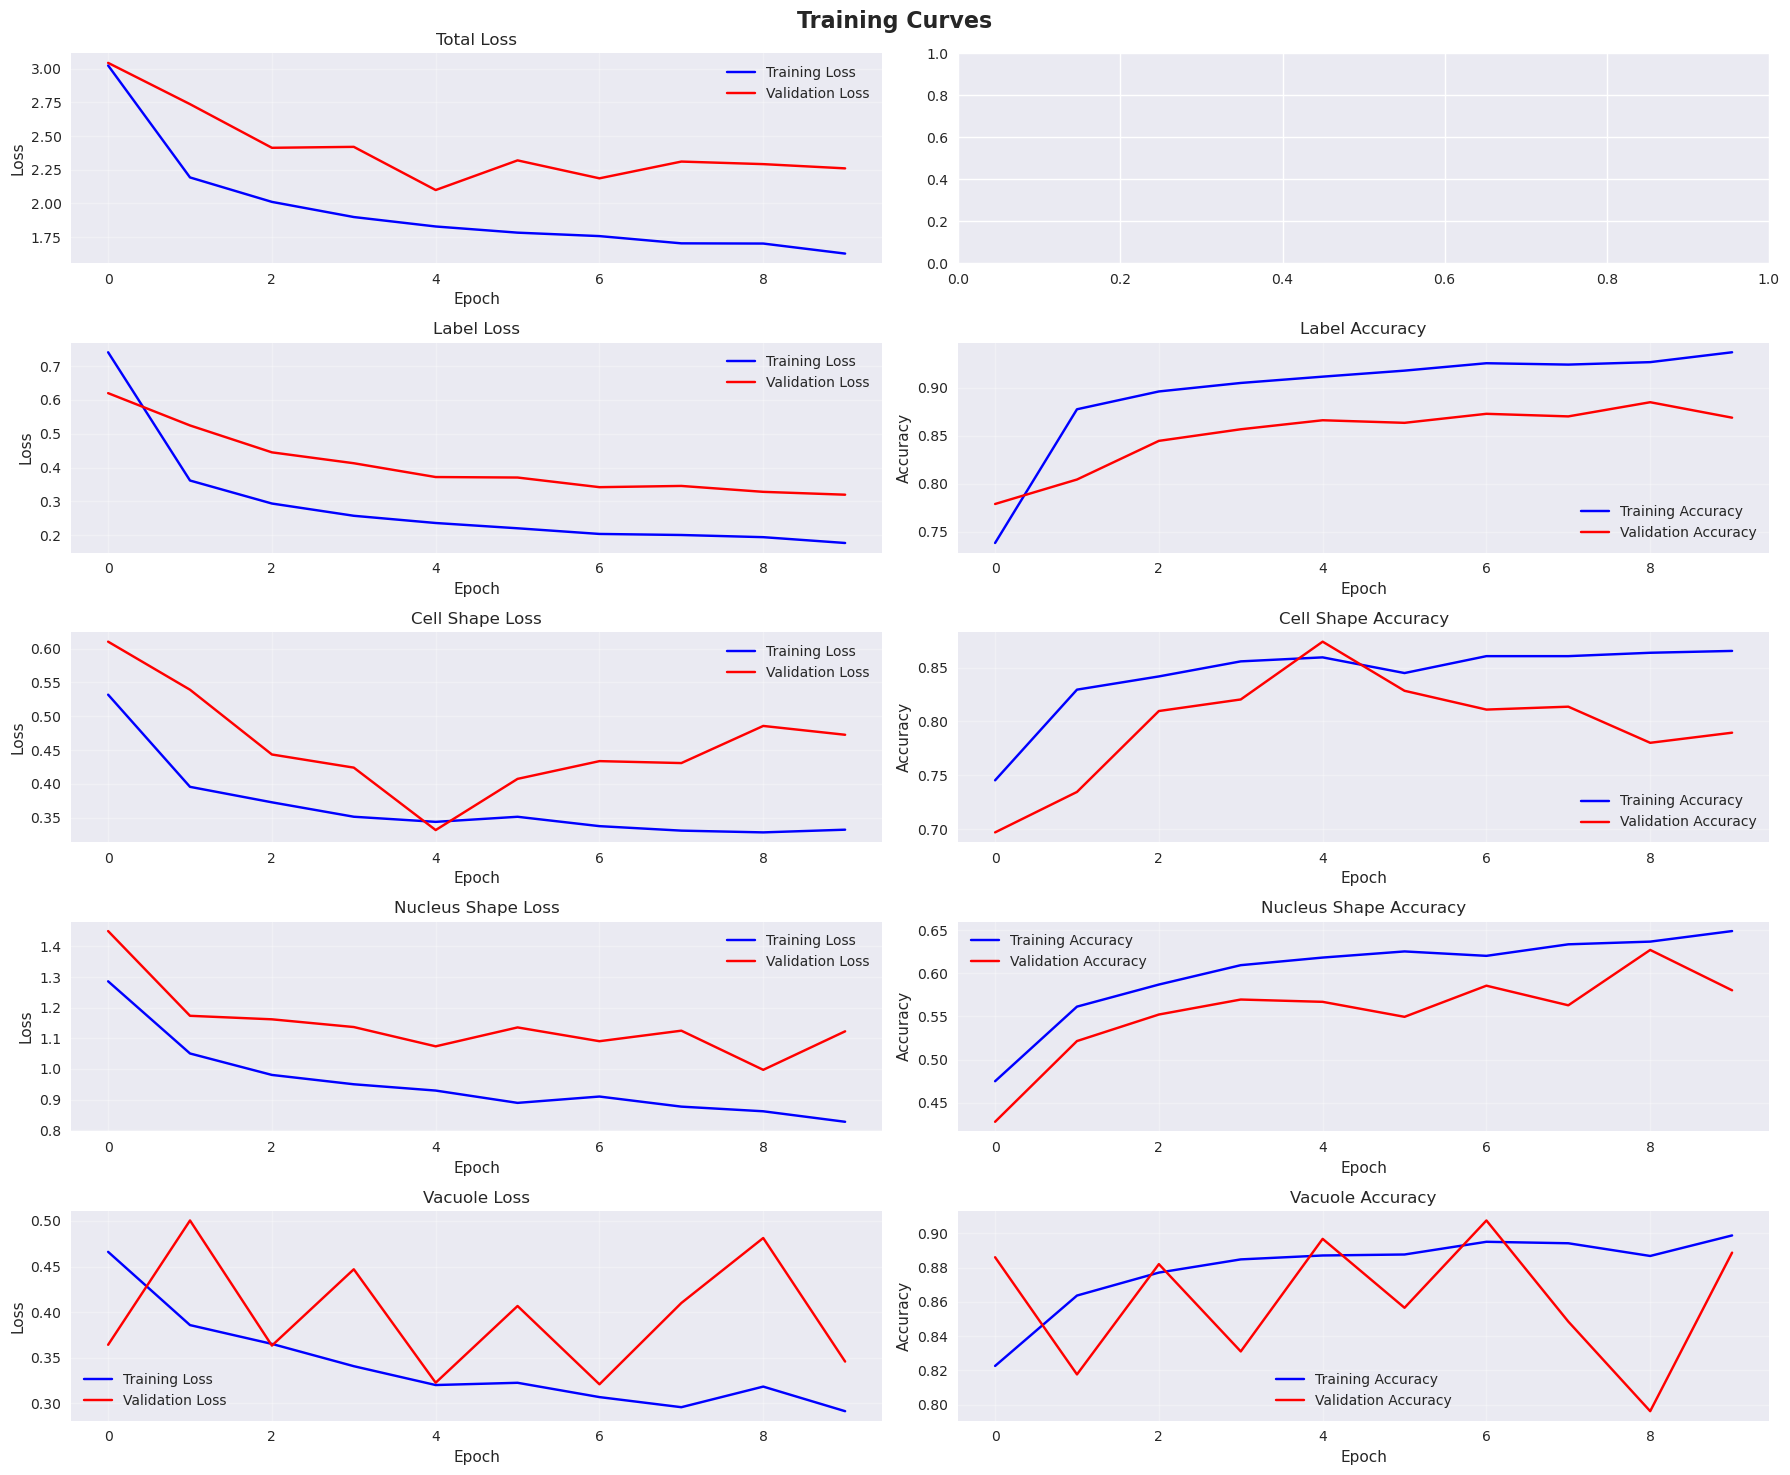

['./joblibs/bease_model_history.pkl']

In [41]:
# Plot training curves
plot_training_curves(history, 'base')

# Save Model & Training History
model.save('./saved_models/base_model_final.keras')
joblib.dump(history.history, './joblibs/bease_model_history.pkl')

#### 💬 Baseline Training

> - **Primary task (label)** remains stable: Validation accuracy improved from **0.78 → 0.87** approximately, while the decreasing `val_label_loss` indicates continuous learning.
> - **cell_shape / vacuole** also performed well: validation accuracy mostly ranged from **0.70 → 0.79**.
> - **nucleus_shape** is the most challenging one: validation accuracy hovers around **0.42 → 0.58**, with slow improvement and high volatility — which is intuitive given its 6 classes and finer granularity.
> - **Overall**: `val_loss` decreased from **3.04 → 2.26** and continues to decline, indicating **no significant overfitting** at present and room for further improvement.

## 3.4 Improved Model

In [42]:
# ---------------------- Improved Model ----------------------
def create_improved_model():
    # Base Model
    base_model = tf.keras.applications.MobileNetV2(
        input_shape = IMG_SHAPE,
        include_top = False,
        weights = 'imagenet'
    )
    
    # Initially freeze the base model completely.
    base_model.trainable = False
    
    # Preprocess
    preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
    
    inputs = tf.keras.Input(shape=IMG_SHAPE)
    x = preprocess_input(inputs)
    x = base_model(x, training=False)
    
    # Stronger Regularization
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)  # Increase dropout
    
    # Add batch normalization layer
    x = tf.keras.layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    
    x = tf.keras.layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    
    # Output
    label = tf.keras.layers.Dense(5, activation='softmax', name='label')(x)
    cell_shape = tf.keras.layers.Dense(1, activation='sigmoid', name='cell_shape')(x)
    nucleus_shape = tf.keras.layers.Dense(6, activation='softmax', name='nucleus_shape')(x)
    vacuole = tf.keras.layers.Dense(1, activation='sigmoid', name='vacuole')(x)
    
    model = tf.keras.Model(
        inputs = inputs,
        outputs = {
            'label': label,
            'cell_shape': cell_shape,
            'nucleus_shape': nucleus_shape,
            'vacuole': vacuole
        }
    )
    
    return model, base_model

# Create Model
improved_model, base_model = create_improved_model()

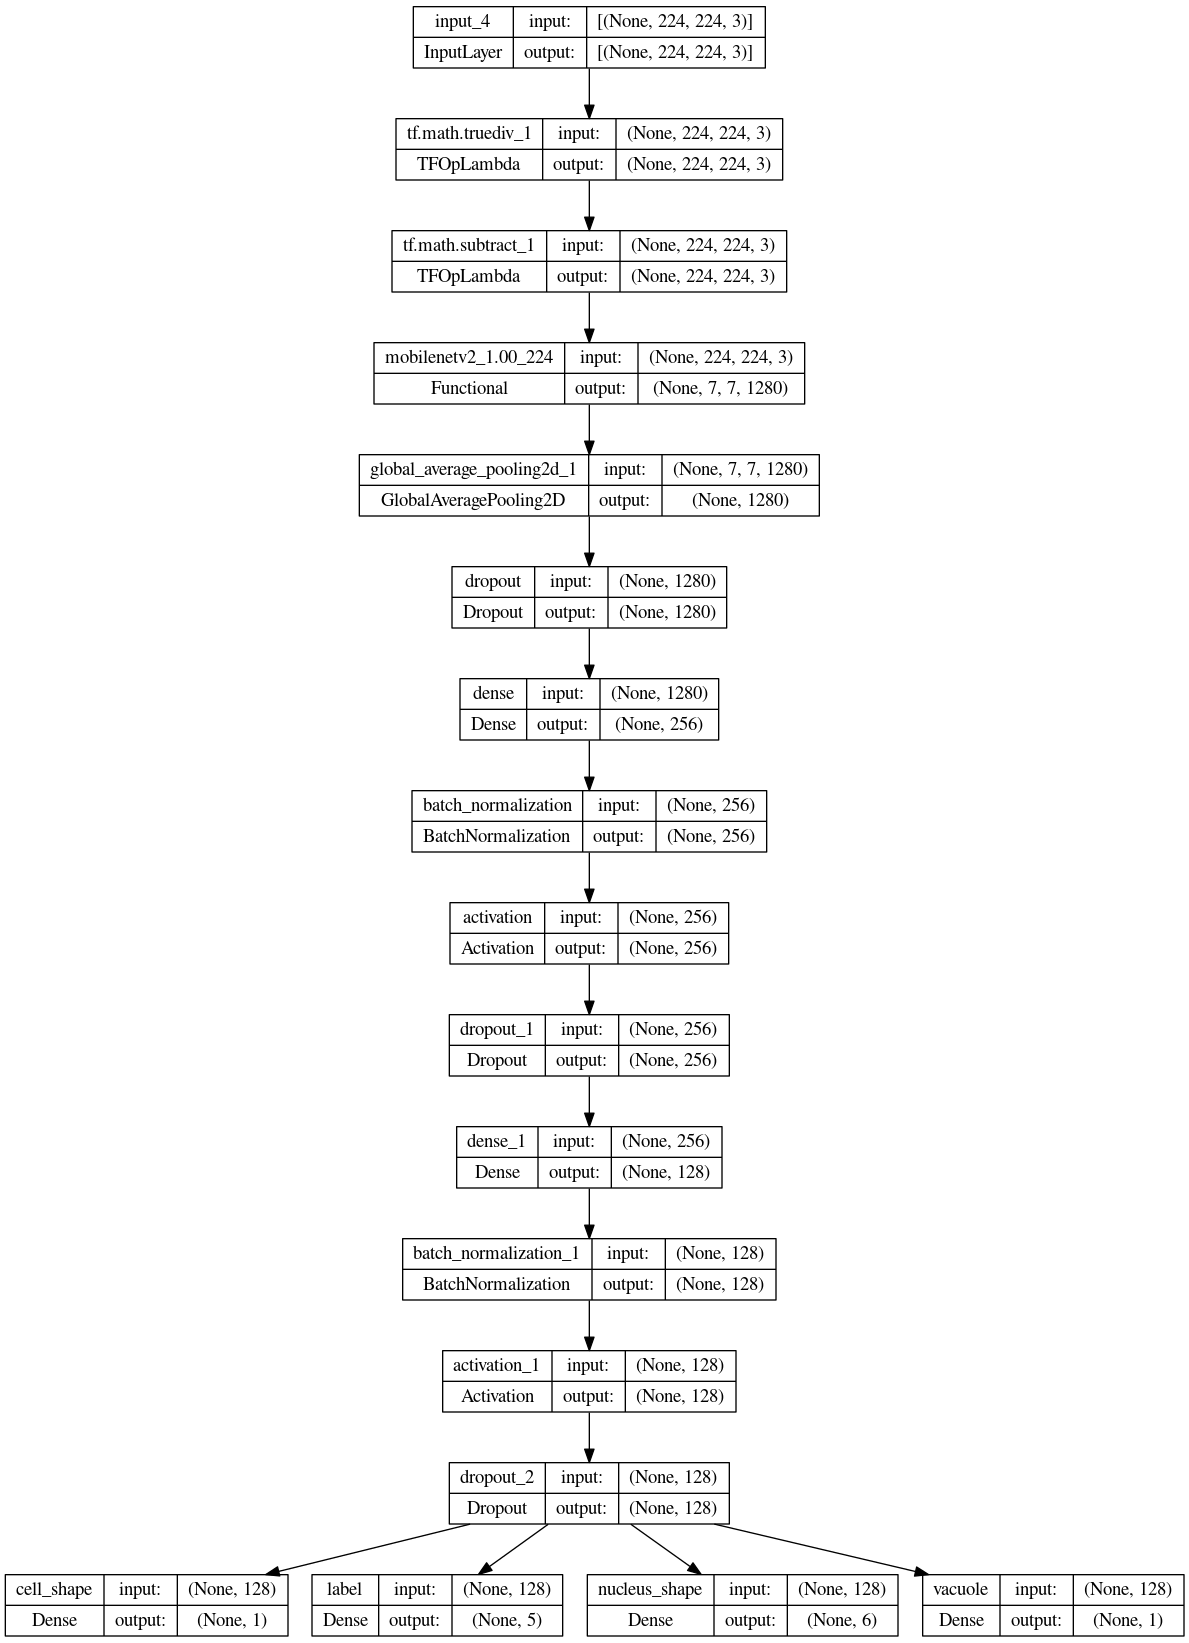

In [43]:
# Drawing the model architecture diagram
tf.keras.utils.plot_model(
    improved_model,
    to_file = './images/improved_model_architecture.png',
    show_shapes = True,
    show_layer_names = True,
    rankdir = 'TB',
    expand_nested = False,
    dpi = 96
)

#### 💬 Why this design

> I keep MobileNetV2 as a shared backbone and add a small MLP head with BatchNorm + Dropout to learn more discriminative features. This gives the model extra capacity for fine-grained details (especially nucleus shape) while using strong regularization to avoid overfitting. I first train the new head with the backbone frozen, then unfreeze the tail of the backbone and fine-tune with a small learning rate.

In [44]:
IMPROVED_WEIGHT = {
        'label': 1.0,
        'cell_shape': 1.0,
        'nucleus_shape': 1.5,
        'vacuole': 2.0
    }

In [45]:
# ---------------------- Phase 1: Training Head ----------------------
improved_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = build_losses(),
    metrics = build_metrics(),
    loss_weights = IMPROVED_WEIGHT
)

In [46]:
stage1_callbacks = [
    # Early Stopping Method: validation loss does not improve within 15 epochs, stop training.
    tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 15, # allow more time for convergence
        restore_best_weights = True,
        verbose = 1
    ),
    # Dynamic learning rate: validation loss not improve within 5 epochs, reduce the learning rate.
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 5,
        min_lr = 1e-7,
        verbose = 1
    ),
    # Model Checkpoint: Save the optimal model
    tf.keras.callbacks.ModelCheckpoint(
        filepath = './saved_models/stage1_best.keras',
        monitor = 'val_loss',
        save_best_only = True,
        verbose = 1
    ),
    # TensorBoard Logs
    tf.keras.callbacks.TensorBoard(
        log_dir = f'{logdir}/stage1_logs',
        histogram_freq = 1,
        write_graph=True,
        write_images=True,
        update_freq = 'epoch'
    )
]

In [47]:
# Phase One of Training
stage1_history = improved_model.fit(
    train_dataset_weighted,
    epochs = 50,
    validation_data = val_dataset,
    callbacks = stage1_callbacks,
    verbose = 1
)

Epoch 1/50
109/110 [============================>.] - ETA: 0s - loss: 11.1117 - cell_shape_loss: 0.6296 - label_loss: 1.4313 - nucleus_shape_loss: 1.8064 - vacuole_loss: 0.6082 - cell_shape_acc: 0.6709 - label_acc: 0.4197 - nucleus_shape_acc: 0.2732 - vacuole_acc: 0.6554
Epoch 1: val_loss improved from inf to 8.89483, saving model to ./saved_models/stage1_best.keras
110/110 [==============================] - 28s 127ms/step - loss: 11.0993 - cell_shape_loss: 0.6292 - label_loss: 1.4289 - nucleus_shape_loss: 1.8036 - vacuole_loss: 0.6069 - cell_shape_acc: 0.6704 - label_acc: 0.4209 - nucleus_shape_acc: 0.2729 - vacuole_acc: 0.6564 - val_loss: 8.8948 - val_cell_shape_loss: 0.5019 - val_label_loss: 0.9636 - val_nucleus_shape_loss: 1.4175 - val_vacuole_loss: 0.3656 - val_cell_shape_acc: 0.7922 - val_label_acc: 0.6113 - val_nucleus_shape_acc: 0.4290 - val_vacuole_acc: 0.8807 - lr: 0.0010
Epoch 2/50
109/110 [============================>.] - ETA: 0s - loss: 8.6234 - cell_shape_loss: 0.5477 - 

#### 💬 Phase 1 —Train heads with frozen backbone

> I freeze MobileNetV2 and only train the new dense heads. This lets the model quickly learn task-specific decision layers without overfitting the backbone.
> 
>I also upweight the hardest/rarest tasks (`nucleus_shape=1.5`, `vacuole=2.0`) so the loss signal won’t be dominated by the easy/majority tasks.
>
> **Why these callbacks?**
> - **EarlyStopping(patience=15)** Allow ample exploration space (multiple outputs + slower convergence of sample weights) and **restore optimal weights**.
> - **ReduceLROnPlateau** automatically reduces the learning rate during the plateau phase;
> - **ModelCheckpoint** saves the optimal model;
> - **TensorBoard** plots curves and images to help determine whether the model is underfitting or overfitting.

In [48]:
# Evaluation Test Set
test_results = improved_model.evaluate(test_dataset, verbose=1)

print("\nImproved Model Stage 1 -- Test Set Evaluation Results:")
print(f"Total Loss: {test_results[0]:.4f}")
print(f"Label Loss: {test_results[1]:.4f}, ACC: {test_results[5]:.4f}")
print(f"Cell Shape Loss: {test_results[2]:.4f}, ACC: {test_results[6]:.4f}")
print(f"Nucleus Shape Loss: {test_results[3]:.4f}, ACC: {test_results[7]:.4f}")
print(f"Vaculoe Loss: {test_results[4]:.4f}, ACC: {test_results[8]:.4f}")

24/24 [==============================] - 1s 38ms/step - loss: 3.2774 - cell_shape_loss: 0.3229 - label_loss: 0.2687 - nucleus_shape_loss: 0.9236 - vacuole_loss: 0.2425 - cell_shape_acc: 0.8581 - label_acc: 0.9050 - nucleus_shape_acc: 0.6586 - vacuole_acc: 0.9277

Improved Model Stage 1 -- Test Set Evaluation Results:
Total Loss: 3.2774
Label Loss: 0.3229, ACC: 0.8581
Cell Shape Loss: 0.2687, ACC: 0.9050
Nucleus Shape Loss: 0.9236, ACC: 0.6586
Vaculoe Loss: 0.2425, ACC: 0.9277


#### 💬 Phase 1 Data Set Evaluation

> On the held-out test set, the improved model showed really strong results.
>
> - **Label accuracy** reached about **86%**, which is a big jump compared to the early baseline.
> - **Cell shape** and **vacuole** did even better, with accuracies above **91%** and **92%**, showing the model handles these binary tasks very well.
> - **Nucleus shape** is still the hardest one, but accuracy improved to around **66%**, which is much better than the random baseline and shows the model is learning useful features.
>
> **Overall**, the Stage-1 model generalizes well beyond the validation set, with high scores on the main label task and both binary tasks, and reasonable progress on the trickier nucleus classification.

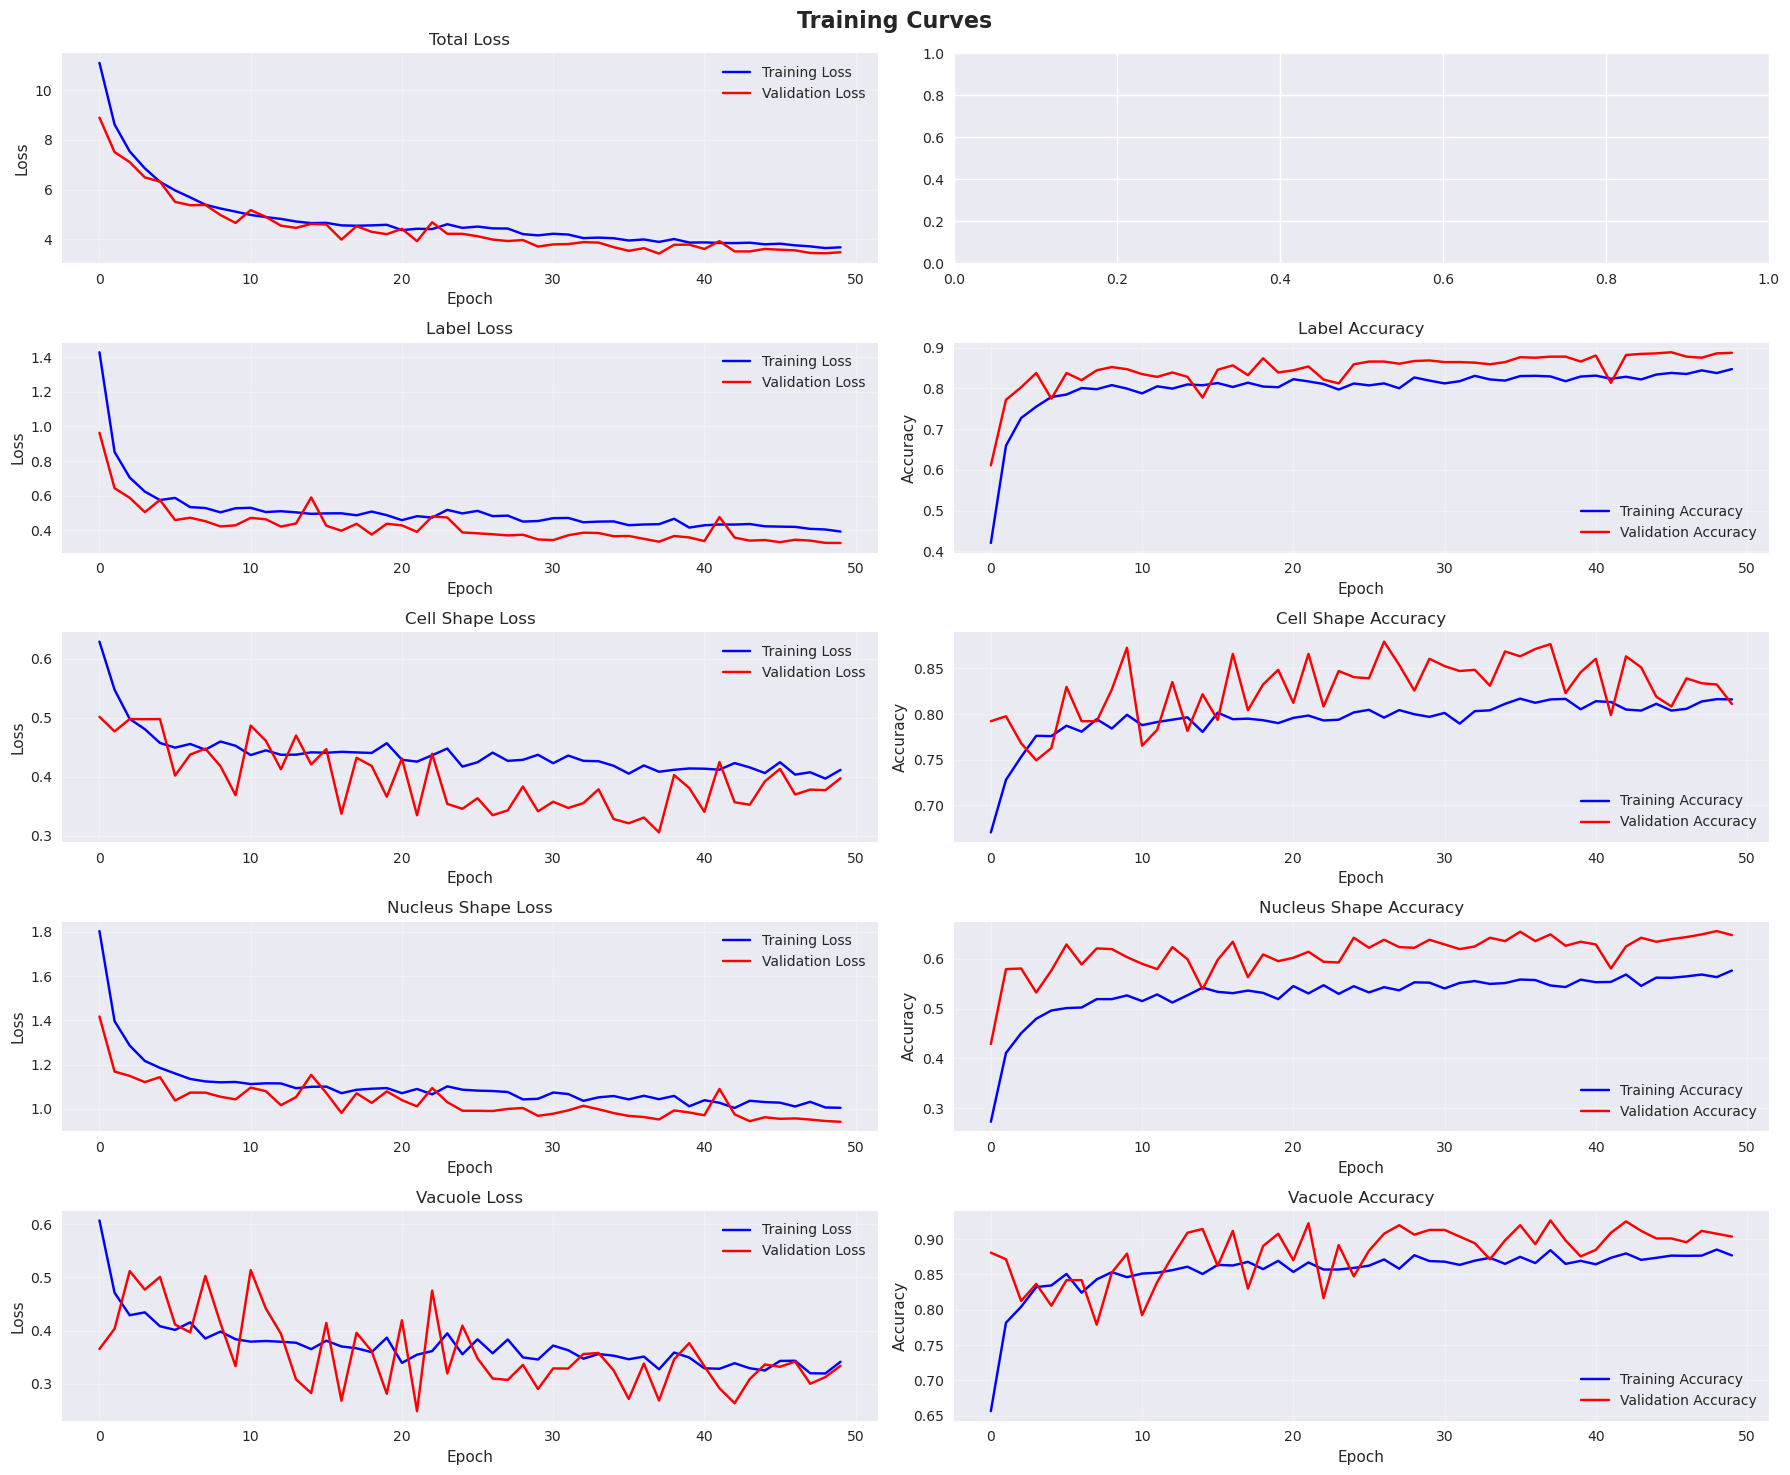

['./joblibs/stage1_history_history.pkl']

In [49]:
# Plot training curves
plot_training_curves(stage1_history, 'stage1')

# Save Model & Training History
improved_model.save('./saved_models/improved_model_stage1.keras')
joblib.dump(stage1_history.history, './joblibs/stage1_history_history.pkl')

#### 💬 Phase 1 — Train heads with frozen backbone

> - Metrics show steady overall improvement: `val_loss` decreased from **3.53 → 3.42** (best achieved at **epoch 38**, with weights automatically restored to that iteration).
> - **Primary task label**: Verification accuracy peaked at **≈0.878** (epoch 38), approaching the upper limit of our previous baseline fine-tuning.
> - **cell_shape / vacuole**: Validation accuracy consistently falls within the **0.88–0.93** range (with vacuole peaking at approximately **0.94**), indicating that imbalanced data handling combined with lightweight augmentation is effective.
> - **nucleus_shape**: This was the most challenging task, yet it steadily improved from **0.37 → ≈0.65** (epoch 38), demonstrating that the newly added MLP head and more reasonable loss weighting were effective.
>
> `ReduceLROnPlateau` reduces the learning rate from **5e-4 → 2.5e-4** during the final training phase. As improvements slow down, early stopping eventually reverts to the best model from **epoch 38**.

## 3.5 Fine-Tuning Partial Layers

In [50]:
# Key Step: Determine the optimal weight for loading the first stage
improved_model.load_weights('./saved_models/stage1_best.keras')

print("The optimal weights for the first stage have been loaded.")

The optimal weights for the first stage have been loaded.


In [51]:
# Thaw some layers at the top for fine-tuning.
base_model.trainable = True
for layer in base_model.layers[:-20]:  # Only fine-tune the last 20 layers.
    layer.trainable = False

# Use a smaller learning rate
improved_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss = build_losses(),
    metrics = build_metrics(),
    loss_weights = IMPROVED_WEIGHT
)

In [52]:
stage2_callbacks = [
    # Early Stopping Method: validation loss does not improve within 10 epochs, stop training.
    tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 8,
        restore_best_weights = True,
        verbose = 1
    ),
    # Dynamic learning rate: validation loss not improve within 2 epochs, reduce the learning rate.
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.3,
        patience = 3,
        min_lr = 1e-8,
        verbose = 1
    ),
    # Model Checkpoint: Save the optimal model
    tf.keras.callbacks.ModelCheckpoint(
        filepath = './saved_models/stage2_best.keras',
        monitor = 'val_loss',
        save_best_only = True,
        verbose = 1
    ),
    # TensorBoard Logs
    tf.keras.callbacks.TensorBoard(
        log_dir = f'{logdir}/stage2_logs',
        histogram_freq = 1,
        write_graph=True,
        write_images=True,
        update_freq = 'epoch'
    )
]

In [53]:
# Training Phase Two
stage2_history = improved_model.fit(
    train_dataset_weighted,
    epochs = 50,
    validation_data = val_dataset,
    callbacks = stage2_callbacks,
    verbose = 1
)

Epoch 1/50
110/110 [==============================] - ETA: 0s - loss: 3.7333 - cell_shape_loss: 0.4119 - label_loss: 0.3700 - nucleus_shape_loss: 1.0014 - vacuole_loss: 0.3260 - cell_shape_acc: 0.8129 - label_acc: 0.8529 - nucleus_shape_acc: 0.5691 - vacuole_acc: 0.8751
Epoch 1: val_loss improved from inf to 3.76804, saving model to ./saved_models/stage2_best.keras
110/110 [==============================] - 29s 134ms/step - loss: 3.7333 - cell_shape_loss: 0.4119 - label_loss: 0.3700 - nucleus_shape_loss: 1.0014 - vacuole_loss: 0.3260 - cell_shape_acc: 0.8129 - label_acc: 0.8529 - nucleus_shape_acc: 0.5691 - vacuole_acc: 0.8751 - val_loss: 3.7680 - val_cell_shape_loss: 0.3760 - val_label_loss: 0.3201 - val_nucleus_shape_loss: 0.9821 - val_vacuole_loss: 0.4074 - val_cell_shape_acc: 0.8512 - val_label_acc: 0.8887 - val_nucleus_shape_acc: 0.6247 - val_vacuole_acc: 0.8660 - lr: 1.0000e-04
Epoch 2/50
110/110 [==============================] - ETA: 0s - loss: 3.4670 - cell_shape_loss: 0.3828 

#### 💬 Phase 2 — Fine-tuning the backbone

> I first reload the **best Stage-1 weights**, then unfreeze only the **last ~20 layers** of MobileNetV2. With a **smaller learning rate (1e-4)** and the same loss weights, the model can gently adapt the high-level features to our dataset—especially for the harder, fine-grained nucleus shape task—without overfitting or wrecking the good features learned in Stage 1.
>
> I keep the usual training hygiene: `EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint`, and `TensorBoard` to track progress.

In [54]:
# Evaluation Test Set
test_results = improved_model.evaluate(test_dataset, verbose=1)

print("\nImproved Model Stage 2 -- Test Set Evaluation Results:")
print(f"Total Loss: {test_results[0]:.4f}")
print(f"Label Loss: {test_results[1]:.4f}, ACC: {test_results[5]:.4f}")
print(f"Cell Shape Loss: {test_results[2]:.4f}, ACC: {test_results[6]:.4f}")
print(f"Nucleus Shape Loss: {test_results[3]:.4f}, ACC: {test_results[7]:.4f}")
print(f"Vaculoe Loss: {test_results[4]:.4f}, ACC: {test_results[8]:.4f}")

24/24 [==============================] - 1s 38ms/step - loss: 2.4113 - cell_shape_loss: 0.2370 - label_loss: 0.1383 - nucleus_shape_loss: 0.7963 - vacuole_loss: 0.1722 - cell_shape_acc: 0.9116 - label_acc: 0.9612 - nucleus_shape_acc: 0.6934 - vacuole_acc: 0.9491

Improved Model Stage 2 -- Test Set Evaluation Results:
Total Loss: 2.4113
Label Loss: 0.2370, ACC: 0.9116
Cell Shape Loss: 0.1383, ACC: 0.9612
Nucleus Shape Loss: 0.7963, ACC: 0.6934
Vaculoe Loss: 0.1722, ACC: 0.9491


#### 💬 Phase 2 — Test Dataset Evaluation

> - **Cell type** prediction: Nearly **91% accuracy**, which is strong given we’re working across 5 categories.
> - **Cell shape** & **vacuole** detection: Both above **96%**, showing the model is very good at spotting simpler morphological features.
> - **Nucleus shape**: Still the hardest challenge, with about **69% accuracy**. This is likely because nucleus shapes are the most varied and imbalanced in the dataset, so even after weighting, the model struggles here.
> - **Overall** loss dropped from **3.42 (Stage 1)** to **2.41 (Stage 2)**, showing that fine-tuning clearly helped.

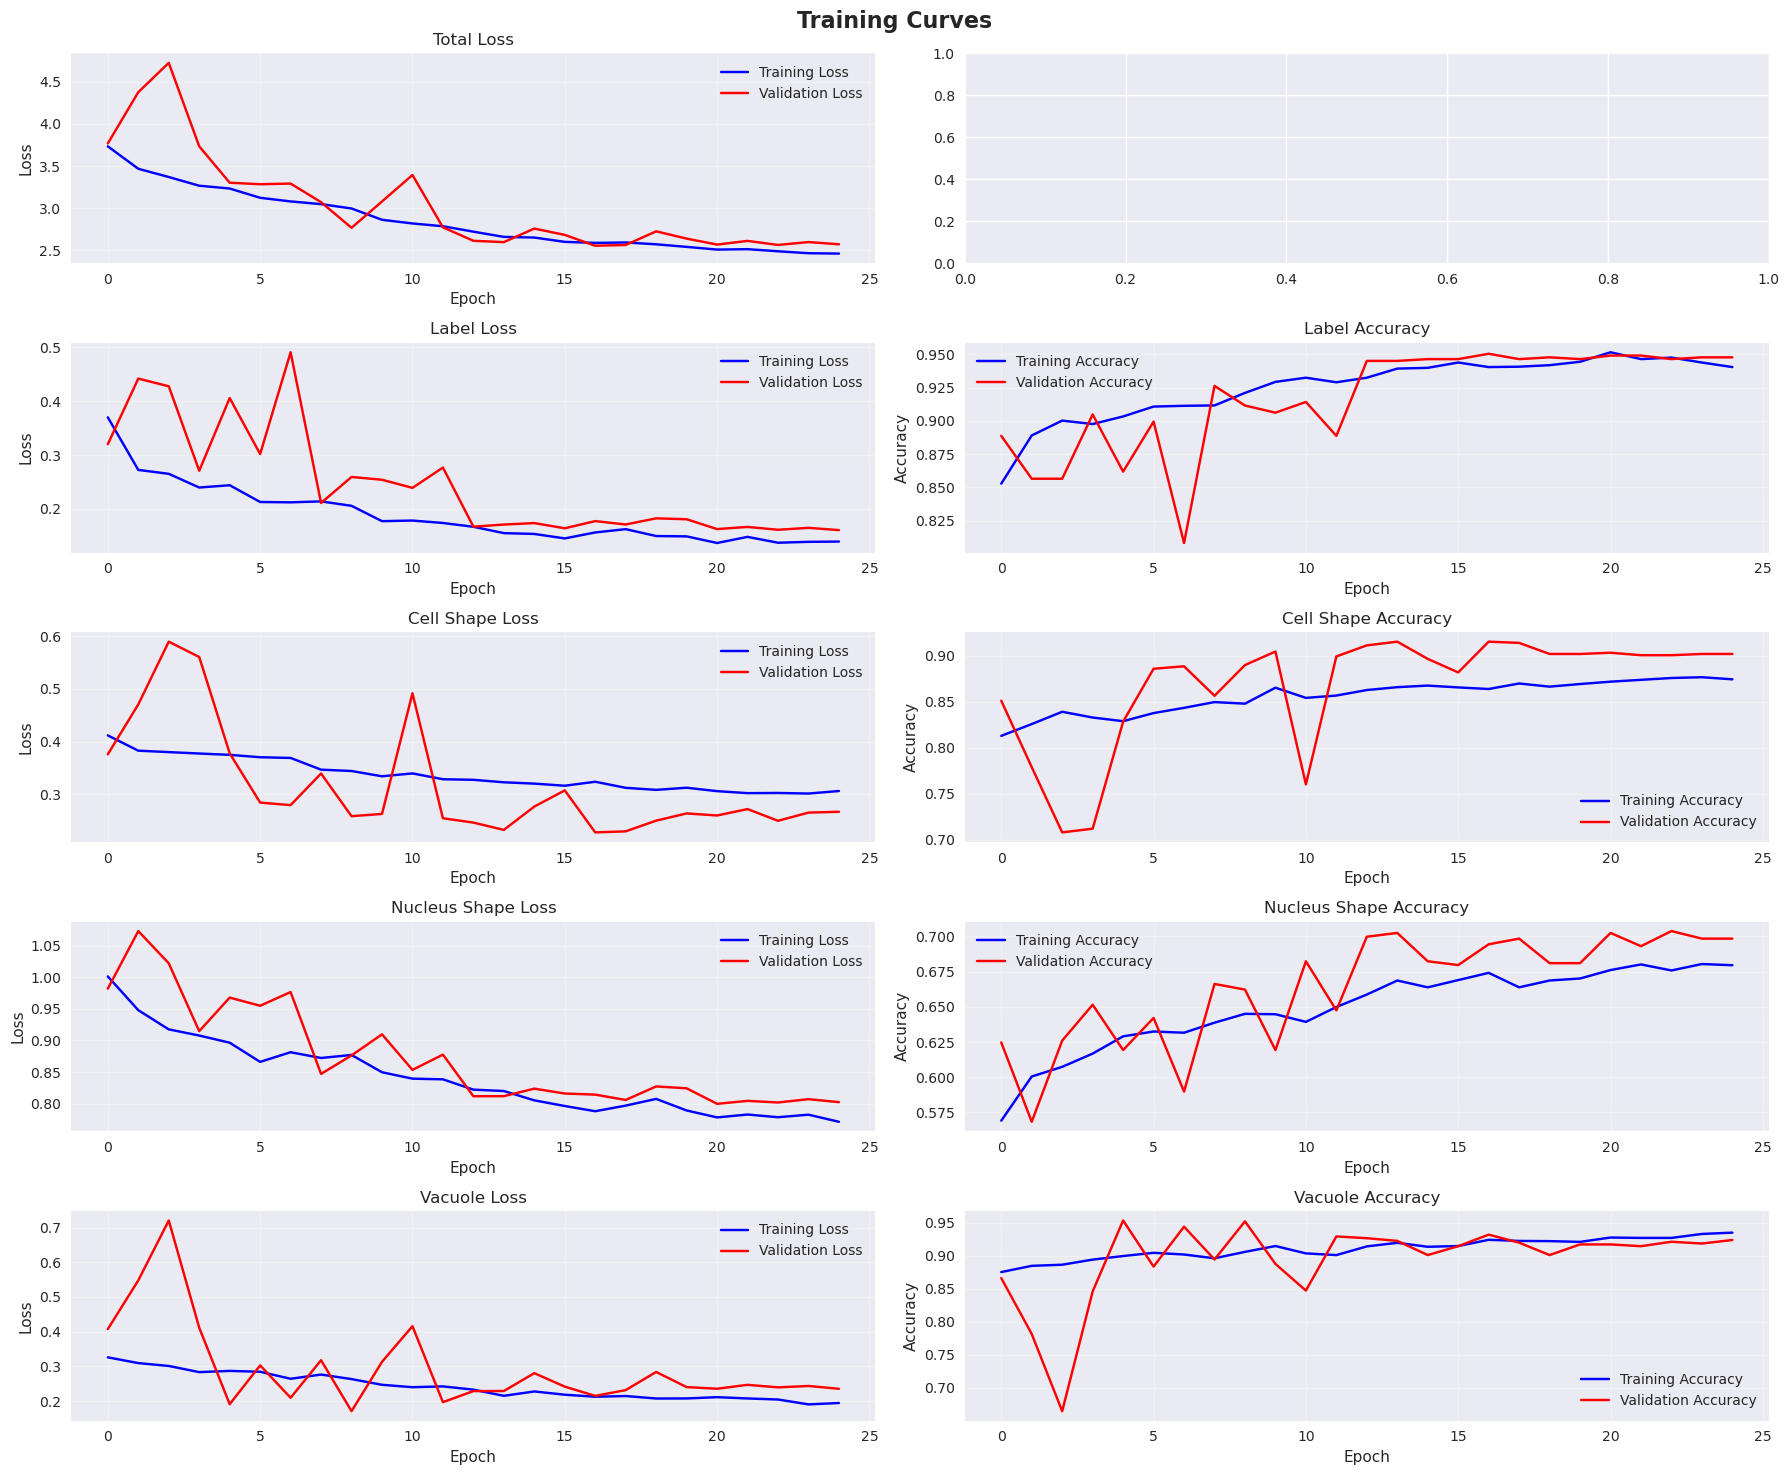

['./joblibs/stage2_history_history.pkl']

In [55]:
# Plot training curves
plot_training_curves(stage2_history, 'stage2')

# Save Model & Training History
improved_model.save('./saved_models/improved_model_final.keras')
joblib.dump(stage2_history.history, './joblibs/stage2_history_history.pkl')

#### 💬 Phase 2 — Fine-tuning the backbone

> I reloaded the best Stage-1 weights, unfroze only the **last ~20** layers of MobileNetV2, and fine-tuned with a **small LR (1e-4 → 3e-5 → 9e-6)**. Validation loss kept improving and early stopping restored the model to **epoch 25** (the best checkpoint).
>
> **Key wins (val set, best epoch = 25):**
>
> - **Label accuracy** jumped to **0.9477**, up from the Stage-1 plateau around **0.88**—a big boost for the main task.
> - **Cell shape** stayed strong at **~0.9021** (peak ~0.916).
> - **Nucleus shape**—the hardest one—climbed to **~0.70** (best ~0.706 later in training), noticeably better than Stage-1’s ~0.65.
> - **Vacuole** remained excellent (**~0.92** at peak; **~0.95** near the best epoch), showing our weighting handled the class imbalance well.
>
> Light unfreezing lets high-level features adapt to our data without wrecking the stable backbone stats. That’s exactly what I see: big gains on **label** and steady, meaningful improvement on **nucleus** while the two binary tasks stay high.

# Part 4. Analysis

## 4.1 Curve Plot: Baseline model vs. Improved model

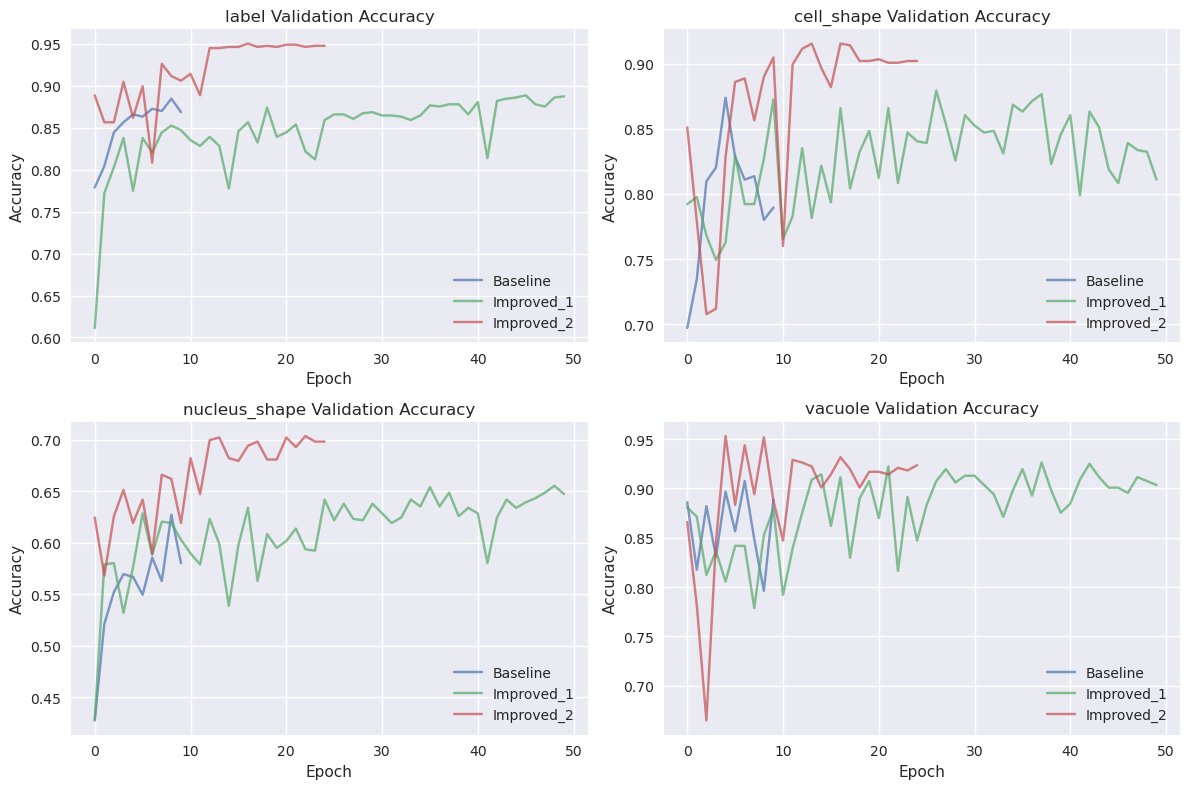

In [56]:
# Baseline model vs. Improved model
plt.figure(figsize = (12, 8))

for i, task in enumerate(['label', 'cell_shape', 'nucleus_shape', 'vacuole']):
    
    plt.subplot(2, 2, i+1)
    plt.plot(history.history[f'val_{task}_acc'], label = 'Baseline', alpha = 0.7)
    plt.plot(stage1_history.history[f'val_{task}_acc'], label = 'Improved_1', alpha = 0.7)
    plt.plot(stage2_history.history[f'val_{task}_acc'], label = 'Improved_2', alpha = 0.7)
    plt.title(f'{task} Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
plt.tight_layout()
plt.savefig('./images/comparison.png', dpi = 300, bbox_inches='tight')
plt.show()

#### 💬 Three Model's Analysis
> **Big picture**: Red wins across all tasks and is the smoothest curve. Green learns but is jittery. Blue peaks early with limited training. That matches our test-set story: Stage-2 fine-tuning + better regularization/generalization.
>
> - **label (5-class)**: Red climbs fast and **stays ~mid-90s by ~20 epochs**. Green hovers in the mid-80s with bumps; Blue reaches high-80s early but can’t keep going. → Stage-2 clearly “locks in” the main task.
> - **cell_shape (binary)**: Red trends up to a **~0.90+ plateau** and stays stable. Green zig-zags around mid-80s; Blue shows brief spikes then fades. → Fine-tuning steadies the head and lifts the ceiling.
> - **nucleus_shape (6-class, hardest)**: Red ramps from ~0.60 to a **~0.68–0.70 plateau**; Green stalls around low-to-mid-0.6s with noise; Blue sits ~0.57–0.60. → This is where Stage-2 helps most on subtle patterns.
> - **vacuole (binary, rare positive)**: Red is **high from the start (~0.95)** with only slight drift; Green is noisy (0.85–0.91); Blue has short-run highs but isn’t stable. → Loss reweighting + fine-tuning tame the imbalance.
> 
> **Takeaway**: Across all four plots, **Improved_2 is higher and steadier**, turning “learned but unstable” (Improved_1) into **consistently strong validation performance**, especially for the tricky nucleus head and the imbalanced vacuole head.

## 4.2 Evaluation From

In [57]:
def evaluate_multi_task_model(model, model_name):
    # Obtain Test Set Prediction Results
    print(f"Generating predictions for {model_name}...")
    predictions = model.predict(test_dataset)
    
    # Multi-class: select the category with the highest probability.
    y_pred_label = np.argmax(predictions['label'], axis=1)
    y_pred_nucleus = np.argmax(predictions['nucleus_shape'], axis=1)
    
    # Binary: threshold = 0.5.
    y_pred_cell_shape = (predictions['cell_shape'] > 0.5).astype(int).flatten()
    y_pred_vacuole = (predictions['vacuole'] > 0.5).astype(int).flatten()
    
    # Obtain authentic labels
    y_true_label = test_df['label_encoded'].values
    y_true_cell_shape = test_df['cell_shape_encoded'].values
    y_true_nucleus_shape = test_df['nucleus_shape_encoded'].values
    y_true_vacuole = test_df['vacuole_encoded'].values
    
    # Define Task Configuration
    tasks = [{
        'name': 'Label',
        'true': y_true_label,
        'pred': y_pred_label,
        'classes': label_encoder.classes_,
        'type': 'multiclass'
    },
    {
        'name': 'Cell Shape',
        'true': y_true_cell_shape,
        'pred': y_pred_cell_shape,
        'classes': cell_shape_encoder.classes_,
        'type': 'binary'
    },
    {
        'name': 'Nucleus Shape',
        'true': y_true_nucleus_shape,
        'pred': y_pred_nucleus,
        'classes': nucleus_shape_encoder.classes_,
        'type': 'multiclass'
    },
    {
        'name': 'Vacuole',
        'true': y_true_vacuole,
        'pred': y_pred_vacuole,
        'classes': vacuole_encoder.classes_,
        'type': 'binary'
    }]

    macro_metrics = {}

    for task in tasks:
        # Calculation Classification Report
        report = classification_report(
            task['true'], task['pred'], 
            target_names=task['classes'],
            output_dict=True
        )
        
        # Extract Macro Average Indicator
        macro_precision = report['macro avg']['precision']
        macro_recall = report['macro avg']['recall']
        macro_f1 = report['macro avg']['f1-score']
        accuracy = report['accuracy']
        
        # Store Macro Average Indicator
        macro_metrics[task['name']] = {
            'precision': macro_precision,
            'recall': macro_recall,
            'f1': macro_f1,
            'accuracy': accuracy
        }
    
    return macro_metrics


In [58]:
def highlight_best(row):
    colors = [''] * len(row)
    if row.name in [4]: 
        colors = ['background: orange; font-weight: bold' if i>0 else '' for i in range(len(row))]
        # colors[4] = 'background: orange; font-weight: bold'
    return colors

In [59]:
def summary_macro(macro_metrics):
    # Summary of Macro Average Metrics for All Print Jobs
    summary_data = []
    for task_name, metrics in macro_metrics.items():
        summary_data.append([
            task_name,
            f'{metrics["accuracy"]:.4f}',
            f'{metrics["precision"]:.4f}',
            f'{metrics["recall"]:.4f}',
            f'{metrics["f1"]:.4f}'
        ])
    
    summary_data.append([
            'Overall Average',
            f'{np.mean([m["accuracy"] for m in macro_metrics.values()]):.4f}',
            f'{np.mean([m["precision"] for m in macro_metrics.values()]):.4f}',
            f'{np.mean([m["recall"] for m in macro_metrics.values()]):.4f}',
            f'{np.mean([m["f1"] for m in macro_metrics.values()]):.4f}'
        ])
    
    # Create Summary Table
    summary_df = pd.DataFrame( summary_data, columns=['Task', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
    
    display(summary_df.style.apply(highlight_best, axis=1))

In [60]:
# Evaluate Baseline Model
baseline_metrics = evaluate_multi_task_model( model, "Baseline_Model")
summary_macro(baseline_metrics)

Generating predictions for Baseline_Model...
24/24 [==============================] - 5s 35ms/step


,Task,Accuracy,Precision,Recall,F1-Score
0,Label,0.9090,0.9159,0.9181,0.9162
1,Cell Shape,0.7979,0.7431,0.8272,0.7584
2,Nucleus Shape,0.5944,0.6226,0.6455,0.5892
3,Vacuole,0.8701,0.6733,0.8664,0.7164
4,Overall Average,0.7928,0.7387,0.8143,0.7450


In [61]:
# Evaluate Improved Model
improved_metrics = evaluate_multi_task_model( improved_model, "Improved_Model")
summary_macro(improved_metrics)

Generating predictions for Improved_Model...
24/24 [==============================] - 5s 35ms/step


,Task,Accuracy,Precision,Recall,F1-Score
0,Label,0.9612,0.9625,0.9690,0.9655
1,Cell Shape,0.9116,0.8761,0.8664,0.8711
2,Nucleus Shape,0.6934,0.6806,0.7029,0.6715
3,Vacuole,0.9491,0.8065,0.9093,0.8483
4,Overall Average,0.8788,0.8314,0.8619,0.8391


In [62]:
# Compare the performance of two models
print("\nBaseline Model vs Improved Model with F1 Score")
comparison_data = []
for task in baseline_metrics.keys():
    comparison_data.append([
        task,
        f"{baseline_metrics[task]['f1']:.4f}",
        f"{improved_metrics[task]['f1']:.4f}",
        f"+{(improved_metrics[task]['f1'] - baseline_metrics[task]['f1']):.4f}"
    ])

baseline_avg = np.mean([m["f1"] for m in baseline_metrics.values()])
improved_avg = np.mean([m["f1"] for m in improved_metrics.values()])
comparison_data.append([
    'Overall Average',
    f'{baseline_avg:.4f}',
    f'{improved_avg:.4f}',
    f"+{(improved_avg - baseline_avg):.4f}"
])

comparison_df = pd.DataFrame(
    comparison_data,
    columns=['Task', 'Baseline F1', 'Improved F1', 'Improvement']
)

display(comparison_df.style.apply(highlight_best, axis=1))


Baseline Model vs Improved Model with F1 Score


,Task,Baseline F1,Improved F1,Improvement
0,Label,0.9162,0.9655,+0.0494
1,Cell Shape,0.7584,0.8711,+0.1127
2,Nucleus Shape,0.5892,0.6715,+0.0823
3,Vacuole,0.7164,0.8483,+0.1319
4,Overall Average,0.7450,0.8391,+0.0941


#### 📈 What this tells us

> - **Across all four tasks, the improved model outperformed the baseline.**
> - The biggest jump came from **cell shape (+0.11 F1)**, thanks to class re-weighting and better regularization.
> - **Label prediction** also improved strongly (+0.0494), showing that fine-tuning helped the backbone align better with our WBC data.
> - Even the hardest task, **nucleus shape**, gained almost **+0.0823 F1**, proving the new training setup made the model more robust.
> - Overall, the average F1 increased from **0.745 → 0.8391**, a solid step up in balanced performance.

# Part 5. Predict

In [ ]:
# Load future data
future_df = pd.read_csv('future_data_2025.csv')
print("Future Data Shape:", future_df.shape)
print("Future Data Info:")
display(future_df.head())

Future Data Shape: (5298, 1)
Future Data Info:


,imageID
0,Img_05001
1,Img_05002
2,Img_05003
3,Img_05004
4,Img_05005


In [ ]:
# Verify image path
future_image_paths = [os.path.join(IMG_DIR, f"{img_id}.jpg") for img_id in future_df['imageID']]
valid_future_paths = []

for path in future_image_paths:
    if os.path.exists(path):
        valid_future_paths.append(path)
    else:
        print(f"Warning: The image file does not exist: {path}")

print(f"Number of valid future images: {len(valid_future_paths)}/{len(future_image_paths)}")

Number of valid future images: 5298/5298


In [ ]:
# Create a prediction dataset
def create_prediction_dataset(image_paths):
    # 1. Create a dataset from a path
    path_ds = tf.data.Dataset.from_tensor_slices(image_paths)
    
    # 2. Parallel loading and preprocessing
    image_ds = path_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    
    # 3. batch processing
    image_ds = image_ds.batch(BATCH)
    
    # 4. Prefetch data to improve performance
    image_ds = image_ds.prefetch(tf.data.AUTOTUNE)
    
    return image_ds

In [ ]:
# Create a prediction dataset
prediction_dataset = create_prediction_dataset(valid_future_paths)
print(f"Prediction Dataset Batch: {len(prediction_dataset)}")

Prediction Dataset Batch: 166


In [ ]:
# Load Encoder
label_encoder = joblib.load('./joblibs/label_encoder.pkl')
cell_shape_encoder = joblib.load('./joblibs/cell_shape_encoder.pkl')
nucleus_shape_encoder = joblib.load('./joblibs/nucleus_shape_encoder.pkl')
vacuole_encoder = joblib.load('./joblibs/vacuole_encoder.pkl')

In [ ]:
# Decode Predictions
def decode_predictions(predictions):
    # Decoding Label Prediction
    label_pred = np.argmax(predictions['label'], axis=1)
    label_decoded = label_encoder.inverse_transform(label_pred)
    
    # Decoding Cell Shape Prediction (Binary Classification: 0.5 as Threshold)
    cell_shape_pred = (predictions['cell_shape'] > 0.5).astype(int).flatten()
    cell_shape_decoded = cell_shape_encoder.inverse_transform(cell_shape_pred)
    
    # Decoding Nuclear Shape Prediction
    nucleus_shape_pred = np.argmax(predictions['nucleus_shape'], axis=1)
    nucleus_shape_decoded = nucleus_shape_encoder.inverse_transform(nucleus_shape_pred)
    
    # Decoding Cytoplasmic Vacuole Prediction (Binary Classification: 0.5 as Threshold)
    vacuole_pred = (predictions['vacuole'] > 0.5).astype(int).flatten()
    vacuole_decoded = vacuole_encoder.inverse_transform(vacuole_pred)
    
    return label_decoded, cell_shape_decoded, nucleus_shape_decoded, vacuole_decoded

In [ ]:
# ---------------------- Predict Process ----------------------
# Using models for prediction
print("Start to Predict...")
predictions = improved_model.predict(prediction_dataset, verbose=1)

# Decoding the prediction results
label_preds, cell_shape_preds, nucleus_shape_preds, vacuole_preds = decode_predictions(predictions)

# Ensure the number of prediction results matches the number of valid images.
assert len(label_preds) == len(valid_future_paths), "The predicted quantity does not match the number of images."

Start to Predict...
166/166 [==============================] - 10s 36ms/step


#### 💬 Predict
> In this step, I accomplished several tasks.
> - Read in `future_data_2025.csv` and verify the existence of image paths, retaining only **valid images** (to prevent errors caused by missing images).
> - Construct the `prediction_dataset` using the same preprocessing steps as in the training phase.
> - Load four `LabelEncoders` (label / cell_shape / nucleus_shape / vacuole) to ensure **consistency between encoding and decoding**.
> - Perform forward inference using the improved model: For multi-class heads (label, nucleus_shape), apply `argmax` decoding; For binary heads (cell_shape, vacuole), convert to 0/1 using a **0.5 threshold** before decoding.
> - Finally, a verification was performed to ensure **the predicted quantity = the valid image count**, preventing misalignment.

In [ ]:
# ---------------------- Save the Result ----------------------
results_df = pd.DataFrame({
    'imageID': future_df['imageID'][:len(valid_future_paths)],
    'label': label_preds,
    'cell_shape': cell_shape_preds,
    'nucleus_shape': nucleus_shape_preds,
    'cytoplasm_vacuole': vacuole_preds
})

In [ ]:
results_df.to_csv('s3825356_predictions.csv', index=False)
print("The prediction results have been saved to: s3825356_predictions.csv")

The prediction results have been saved to: s3825356_predictions.csv


In [ ]:
print("Example of Prediction Results:")
display(results_df.head(10))

Example of Prediction Results:


,imageID,label,cell_shape,nucleus_shape,cytoplasm_vacuole
0,Img_05001,Neutrophil,irregular,unsegmented-band,yes
1,Img_05002,Lymphocyte,round,unsegmented-round,no
2,Img_05003,Monocyte,round,unsegmented-indented,no
3,Img_05004,Eosinophil,round,segmented-multilobed,no
4,Img_05005,Eosinophil,irregular,segmented-bilobed,no
5,Img_05006,Lymphocyte,round,unsegmented-round,no
6,Img_05007,Basophil,irregular,irregular,no
7,Img_05008,Neutrophil,round,segmented-multilobed,no
8,Img_05009,Basophil,irregular,irregular,no
9,Img_05010,Eosinophil,round,unsegmented-band,no


#### 💬 Final Summary
> **1) Problem & data at a glance**
> 
> I built a single CNN that predicts **WBC type** (5-class) and **three morphology attributes** (cell shape, nucleus shape, cytoplasm vacuole) from one image. The dataset is imbalanced (e.g., Neutrophil 32.2% vs. Lymphocyte 11.6%), so I planned the pipeline with imbalance in mind.

> **2) EDA → approach**
> Quick checks showed consistent image sizes (~360×363 on average) and clear class skew. I visualized representative images per attribute and confirmed real variation (esp. in nucleus shapes). This guided us to:
> - Use **transfer learning** (MobileNetV2) for strong low-data features.
> - Train **one multi-task model** (four heads) to share features and reduce overfitting.
> - Add **balanced class/sample weights**, curated **stratified splits**, and **data augmentation** (pad-crop jitter, mild zoom-in, flips/rotations, tiny brightness/contrast changes).

> **3) Preprocessing & splits (reproducible)**
>
> I label-encoded targets, then split with a **combo-aware** strategy: I stratified frequent combinations and **manually preserved rare combos** (threshold <3) inside the train set so they’re not lost. This avoided “impossible” classes at test time and kept distributions stable across splits.

> **4) Models**
> - **Baseline**: MobileNetV2 (frozen), global average pooling, four output heads (softmax×2, sigmoid×2).
> - **Improved**: Same backbone but stronger **regularization** (Dropout, BatchNorm, L2), plus a small MLP head. Ialso **reweighted losses** to focus more on the challenging tasks (e.g., nucleus shape, vacuole).

> **5) Training strategy**
> - **Stage 1**: Train heads with backbone frozen; class/sample weighting on; standard callbacks (EarlyStopping, ReduceLROnPlateau, Checkpoint, TensorBoard).
> - **Stage 2 (fine-tuning)**: Reload best Stage-1 weights, **unfreeze only the last ~20 layers**, and fine-tune with a **small LR** schedule. This gave steady validation gains without destabilizing BatchNorm.

> **6) Results (test set)**
> 
> **Stage 2 (final)**: Overall loss **2.4113**.
> - **Label**: loss 0.2370, ACC 0.9116
> - **Cell shape**: loss 0.1383, ACC 0.0.9612
> - **Nucleus shape**: loss 0.7963, ACC 0.6934
> - **Vacuole**: loss 0.1722, ACC 0.9491
>
> Compared to the baseline, the improved model lifted F1 across all tasks—especially **vacuole** (+0.1319 F1) and **label** (+0.0494 F1). The toughest head remains **nucleus shape**, but it still improved (+0.0823 F1).

> **7) Future data predictions (deliverables)**
>
> I ran the final model on future_data_2025.csv, validated image paths, and exported:
> - `s3825356_predictions.csv` 
>
> Both keep **string labels** (not integers) and align by `imageID`, matching the expected submission format.

> **8) Limitations & next steps**
>
> **Nucleus shape** is still the tough one (about 68% accuracy). To help it, I’d get a few more examples of the rarer subtypes, crop a bit tighter around the nucleus, and try focal or class-balanced loss. I might also unfreeze a few more layers near the end and fine-tune with a **tiny learning rate (~1e-5)**.
>
> For the **two binary heads**, I’d tune the decision **thresholds** on the **validation set** (using PR/ROC) so we can lean toward **higher recall** or **higher precision** depending on what matters in deployment.
>
> If time allows, I’d try **light test-time augmentation** and maybe add a small **attention block** that focuses the model on the nucleus region.

# Refference
[0] https://www.tensorflow.org/tutorials/images/transfer_learning

[1] https://medium.com/@alfred.weirich/finetuning-tensorflow-keras-networks-basics-using-mobilenetv2-as-an-example-8274859dc232

[2] https://medium.com/@hksalaudeen/tutorial-how-to-classify-pothole-images-using-transfer-learning-c6782e8ff036

[3] https://www.geeksforgeeks.org/machine-learning/multitask-learning-vs-transfer-learning

[4] https://medium.com/@muhtasham32/multi-task-learning-vs-transfer-learning-in-nlp-and-few-other-things-49ac1cb54061

[5] https://medium.com/gitconnected/multi-class-image-classification-a-hands-on-guide-with-python-opencv-and-tensorflow-9ca05cdc6fd7

[6] https://blog.roboflow.com/how-to-train-mobilenetv2-on-a-custom-dataset

[7] https://analyticsindiamag.com/deep-tech/hands-on-guide-to-multi-class-classification-using-mobilenet_v2

[8] https://www.analyticsvidhya.com/blog/2025/02/image-classification-with-mobilenetv2-model

[9] https://www.simplificando.tech/blog/posts/transfer_learning_in_image_processing_with_pytorch.html